<a href="https://colab.research.google.com/github/armeros/DC_Visual_Matplotlib/blob/main/matplotlib_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt, numpy as np, pandas as pd
pd.options.display.float_format = '{:,.2f}'.format

>> *The materials in this topic will be covered super fast.  Any generative A.I. can give you the code to produce the graph you want and coding this does not require any logic other than you memorizing the syntax.  I found it less and less interesting and these may be omitted in the next semester.*

# ***Plotting***

This ipynb file consists of the material from

- Quant Econ [Matplotlib](https://python-programming.quantecon.org/matplotlib.html)
- Quant Econ Datascience [Plotting](https://datascience.quantecon.org/scientific/plotting.html)
- Data Camp Intermediate Python Course: [Matplotlib](https://campus.datacamp.com/courses/intermediate-python/matplotlib?ex=1)
- Data Camp [Introduction to Data Visualization with Matplotlib](https://app.datacamp.com/learn/courses/introduction-to-data-visualization-with-matplotlib)

Since I assume you should have known the first two from the last semester, we'll go through them super quick.  The rest will also be quick as I think this topic is less and less important with generative A.I.

>> People out there usually use Seaborn package more than Matplotlib. You will need to learn it yourself by learning through Data Camp [Seaborn](https://app.datacamp.com/learn/courses/introduction-to-data-visualization-with-seaborn)'s course.

# ***Matplotlib’s Split Personality***

Matplotlib offers 2 different interfaces to plotting.

 - One is a simple ***MATLAB-style API*** (Application Programming Interface) that was written to help MATLAB refugees find a ready home.

 >>> **`MATLAB`** used to be a programming language in many top **ECON** programs in the states and oceania.  It still has its place in some institutions but pales in comparison to **`Python`**.

- The other is a more “Pythonic” ***object-oriented*** API.

For reasons described below, we recommend that you use the second API. But first, let’s discuss the difference.

## ***The MATLAB-style API***

Here’s the kind of easy example you might find in introductory treatments.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 200)
y = np.sin(x)

plt.plot(x, y, 'b-', linewidth=2)
plt.show()

This is simple and convenient, but also somewhat limited and un-Pythonic.

For example, in the function calls **`plt.plot()`**, a lot of objects get created and passed around without making themselves known to the programmer.

Python programmers tend to prefer a more explicit style of programming (run **`import this`** in a code block and look at the second line).

This leads us to the alternative, object-oriented Matplotlib API.

## ***The Object-Oriented API***

Here’s the code corresponding to the preceding figure using the object-oriented API.

>> Most of the codes you get from asking any generative A.I. will come in this format.

In [ ]:
# Create a figure and axis object which stores the information from our graph.
fig, ax = plt.subplots()

# Generate data that we will plot.
x = np.linspace(0, 10, 200)
y = np.sin(x)

# Use the x and y data, and make a line plot on our axis, ax, by calling the plot method.
ax.plot(x, y, 'b-', linewidth=2)
plt.show()

## ***Difference between Figure and Axis***

- The figure is the entire framed painting (which inclues the axis itself).
- The axis is the canvas; it is where we “draw” our plots.

In [ ]:
fig, ax = plt.subplots()

fig.set_facecolor("red")
ax.set_facecolor("blue")

Here the call **`fig, ax = plt.subplots()`** returns a pair, where

- `fig` is a `Figure` instance—like a blank canvas.  
- `ax` is an `AxesSubplot` instance—think of a frame for plotting in.  


The `plot()` function is actually a method of `ax`.

While there’s a bit more typing, the more explicit use of objects gives us better control.

### ***Tweaks***

Here we’ve changed the line to red and added a `legend`

In [ ]:
fig, ax = plt.subplots()

x = np.linspace(0, 10, 200)
y = np.sin(x)

ax.plot(x, y, 'r-', linewidth=2, label='sine function', alpha=0.6)
ax.legend()
plt.show()

>> Those keyword arguments you saw above, e.g.,
 - `linewidth=`
 - `label=`
 - `alpha=`

>> are less and less worthwhile to get familiar with.  Generative A.I. can give you those.

The location of the `legend` can be changed by replacing **`ax.legend()`** with **`ax.legend(loc='upper center')`**.

In [ ]:
fig, ax = plt.subplots()

x = np.linspace(0, 10, 200)
y = np.sin(x)

ax.plot(x, y, 'r-', linewidth=2, label='sine function', alpha=0.6)
ax.legend(loc='upper center')
plt.show()

## ***$\LaTeX$ Integration***

If everything is properly configured, then adding $\LaTeX$ is trivial.

In [ ]:
fig, ax = plt.subplots()

x = np.linspace(0, 10, 200)
y = np.sin(x)

# LaTeX command in matplotlib starts with the letter r'$ $' where r means raw string
# and $$ is the quotation mark for LaTeX expression.
ax.plot(x, y, 'r-', linewidth=2, label=r'$y=\sin(x)$', alpha=0.6)
ax.legend(loc='upper center')
plt.show()

## ***Ticks and Titiles***

Controlling the ticks, adding titles and so on is also straightforward

In [ ]:
fig, ax = plt.subplots()

x = np.linspace(0, 10, 200)
y = np.sin(x)

ax.plot(x, y, 'r-', linewidth=2, label=r'$y=\sin(x)$', alpha=0.6)
ax.legend(loc='upper center')
ax.set_yticks([-1, 0, 1])
ax.set_title('Test plot')
plt.show()

## ***Multiple Plots on One Axis***

It’s straightforward to generate multiple plots on the same axes.

Here’s an example that randomly generates three normal densities and adds a label with their mean.

In [ ]:
from scipy.stats import norm
from random import uniform

fig, ax = plt.subplots()
x = np.linspace(-4, 4, 150)
for i in range(3):
    m, s = uniform(-1, 1), uniform(1, 2)
    y = norm.pdf(x, loc=m, scale=s)
    current_label = rf'$\mu = {m:.2}$' # rf" " is raw f-string
    ax.plot(x, y, linewidth=2, alpha=0.6, label=current_label)
ax.legend()
plt.show()

## ***Multiple Subplots***
Sometimes we want multiple subplots in one figure.

Here’s an example that generates 6 histograms

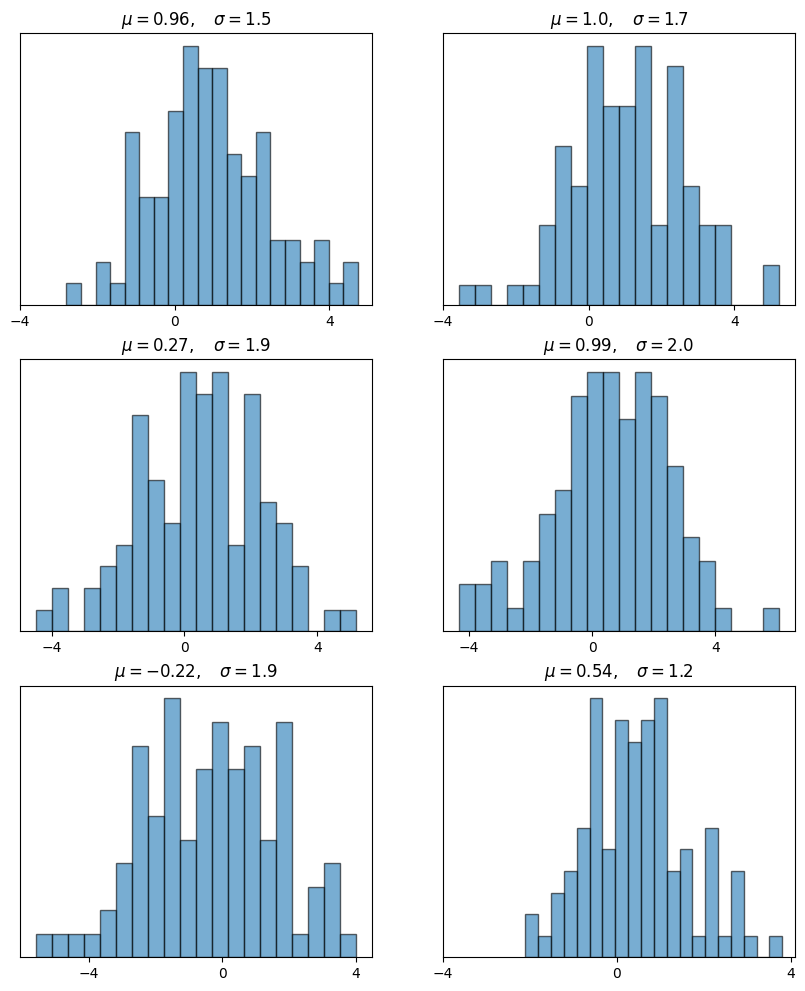

In [ ]:
num_rows, num_cols = 3, 2
fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 12))
for i in range(num_rows):
    for j in range(num_cols):
        m, s = uniform(-1, 1), uniform(1, 2)
        x = norm.rvs(loc=m, scale=s, size=100)
        axes[i, j].hist(x, alpha=0.6, bins=20, edgecolor='black')
        t = rf'$\mu = {m:.2}, \quad \sigma = {s:.2}$'
        axes[i, j].set(title=t, xticks=[-4, 0, 4], yticks=[])
plt.show()

## ***3D Plots***
Matplotlib does a nice job of 3D plots — here is one example.

>> You are unlikely to have to plot anything in 3 dimensional space, especially if you are not a theory person.
>> - It is probably easier to ask for A.I. code to do this.

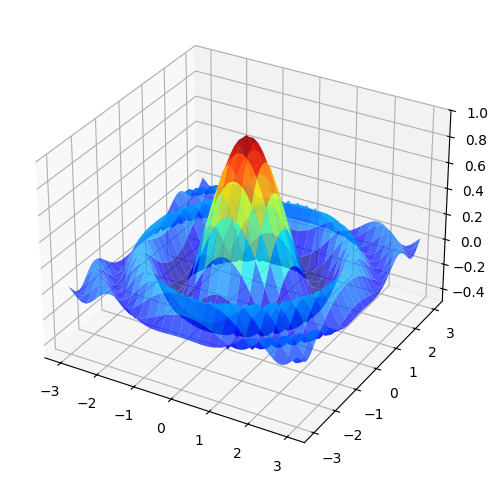

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm

def f(x, y):
    return np.cos(x**2 + y**2) / (1 + x**2 + y**2)

# In 2D you need one grid.  In 3D you need 2 grids
xgrid = np.linspace(-3, 3, 50)
ygrid = xgrid

# Build surface for plotting
x, y = np.meshgrid(xgrid, ygrid)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x,
                y,
                f(x, y),
                rstride=2, cstride=2,
                cmap=cm.jet,
                alpha=0.7,
                linewidth=0.25)
ax.set_zlim(-0.5, 1.0)
plt.show()

You might wanna try to plot any function you learn from other subjects.  For example, $F(K, L) = K^{\frac{1}{3}}L^{\frac{2}{3}}$

## ***A Customizing Function***

Perhaps you will find a set of customizations that you regularly use.

Suppose we usually prefer our axes to go through the origin, and to have a grid.

Here’s a nice example from Matthew Doty of how the object-oriented API can be used to build a custom subplots function that implements these changes.

Read carefully through the code and see if you can follow what’s going on

In [ ]:
def subplots():
    "Custom subplots with axes through the origin"
    fig, ax = plt.subplots()

    # Set the axes through the origin
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_position('zero')
    for spine in ['right', 'top']:
        ax.spines[spine].set_color('none')

    ax.grid()
    return fig, ax


fig, ax = subplots()  # Call the local version, not plt.subplots()
x = np.linspace(-2, 10, 200)
y = np.sin(x)
ax.plot(x, y, 'r-', linewidth=2, label='sine function', alpha=0.6)
ax.legend(loc='lower right')
plt.show()

The custom `subplots` function

- calls the standard **`plt.subplots`** function internally to generate the `fig, ax` pair,

- makes the desired customizations to `ax`, and

- passes the `fig, ax` pair back to the calling code.

## ***Style Sheets***

Another useful feature in Matplotlib is [style sheets](https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html).

We can use style sheets to create plots with uniform styles.

We can find a list of available styles by printing the attribute **`plt.style.available`**

In [ ]:
print(plt.style.available)

We can now use the plt.style.use() method to set the style sheet.

Let’s write a function that takes the name of a style sheet and draws different plots with the style

In [ ]:
from scipy.stats import norm
from random import uniform

def draw_graphs(style='default'):

    # Setting a style sheet
    plt.style.use(style)

    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
    x = np.linspace(-13, 13, 150)

    # Set seed values to replicate results of random draws
    np.random.seed(9)

    for i in range(3):

        # Draw mean and standard deviation from uniform distributions
        m, s = np.random.uniform(-8, 8), np.random.uniform(2, 2.5)

        # Generate a normal density plot
        y = norm.pdf(x, loc=m, scale=s)
        axes[0].plot(x, y, linewidth=3, alpha=0.7)

        # Create a scatter plot with random X and Y values
        # from normal distributions
        rnormX = norm.rvs(loc=m, scale=s, size=150)
        rnormY = norm.rvs(loc=m, scale=s, size=150)
        axes[1].plot(rnormX, rnormY, ls='none', marker='o', alpha=0.7)

        # Create a histogram with random X values
        axes[2].hist(rnormX, alpha=0.7)

        # and a line graph with random Y values
        axes[3].plot(x, rnormY, linewidth=2, alpha=0.7)

    style_name = style.split('-')[0]
    plt.suptitle(f'Style: {style_name}', fontsize=13)
    plt.show()

draw_graphs(style='seaborn-v0_8')

We can use grayscale to remove colors in plots

In [ ]:
draw_graphs(style='grayscale')

Here is what ggplot looks like

In [ ]:
draw_graphs(style='ggplot')

We can also use the style dark_background

In [ ]:
draw_graphs(style='dark_background')

#### ***Exercise 11.1***

Plot the function

$$
f(x) = \cos(\pi \theta x) \exp(-x)
$$

over the interval $ [0, 5] $ for each $ \theta $ in `np.linspace(0, 2, 10)`.

Place all the curves in the same figure.

The output should look like this

![https://python-programming.quantecon.org/_static/lecture_specific/matplotlib/matplotlib_ex1.png](https://python-programming.quantecon.org/_static/lecture_specific/matplotlib/matplotlib_ex1.png)

In [ ]:
def subplots():
    "Custom subplots with axes through the origin"
    fig, ax = plt.subplots()

    # Set the axes through the origin
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_position('zero')
    for spine in ['right', 'top']:
        ax.spines[spine].set_color('none')

    # ax.grid()
    return fig, ax

fig, ax = subplots()
x = np.linspace(0, 5, 200)
for θ in np.linspace(0, 2, 10):
    y = np.cos(np.pi*θ*x) * np.exp(-x)
    ax.plot(x, y, linewidth=2, label=rf'$\theta = {θ:.2f}$', alpha=0.6)
ax.legend(loc='upper right')
plt.show()

## ***Functionality***

What you have seen so far is how to plot theoretical graphs.  Never will you ever plot these unless you are working on theory paper.  However, sometimes you might need to know how to plot these e.g. adding a regression line.

### ***Bar Plot***

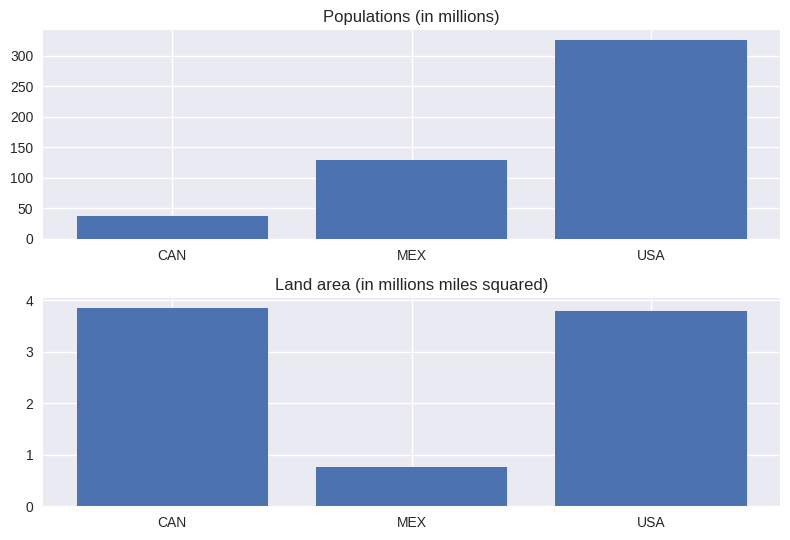

In [ ]:
countries = ["CAN", "MEX", "USA"]
populations = [36.7, 129.2, 325.700]
land_area = [3.850, 0.761, 3.790]

fig, ax = plt.subplots(2)

ax[0].bar(countries, populations, align="center")
ax[0].set_title("Populations (in millions)")

ax[1].bar(countries, land_area, align="center")
ax[1].set_title("Land area (in millions miles squared)")

fig.tight_layout()

You have seen how to plot this using pandas.

,populations,land_area
countries,,
CAN,36.7,3.850
MEX,129.2,0.761
USA,325.7,3.790


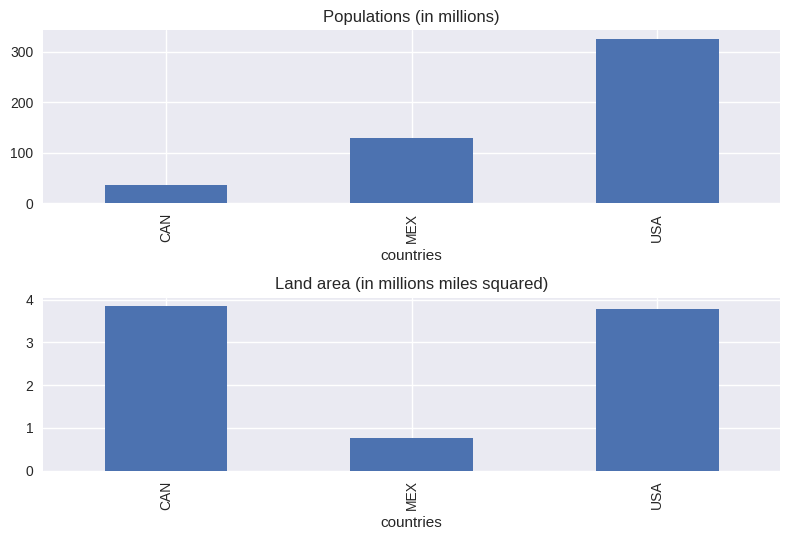

In [ ]:
import pandas as pd

df = pd.DataFrame(data={'populations': [36.7, 129.2, 325.700],
                        'land_area':[3.850, 0.761, 3.790],
                        'countries': ["CAN", "MEX", "USA"]}).set_index('countries')
display(df)

fig, ax = plt.subplots(2)

df['populations'].plot(kind='bar', ax=ax[0], align='center')
ax[0].set_title("Populations (in millions)")

df['land_area'].plot(kind='bar', ax=ax[1], align='center')
ax[1].set_title("Land area (in millions miles squared)")

fig.tight_layout()
plt.show()

>> You may have to memorize how to do these before generative A.I. exists.

## ***Scatter plot and annotation***

Text(25, -25, 'First point')

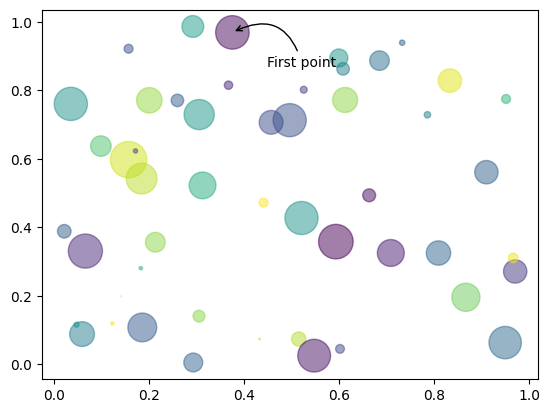

In [ ]:
import matplotlib.pyplot as plt, numpy as np, pandas as pd

N = 50
np.random.seed(42)

x = np.random.rand(N)
y = np.random.rand(N)
colors = np.random.rand(N)
area = np.pi * (15 * np.random.rand(N))**2  # 0 to 15 point radii

fig, ax = plt.subplots()

# s: size, c: color, alpha: opaqcity
ax.scatter(x, y, s=area, c=colors, alpha=0.5)

ax.annotate(
    "First point", xy=(x[0], y[0]), xycoords="data",
    xytext=(25, -25), textcoords="offset points",
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.6")
)

You are on you own to find the functions of

- `xy=(x[0], y[0])` →
- `xycoords="data"` →
- `xytext=(25, -25)` →
- `textcoords="offset points"` →
- `arrowprops`

>> Note also that you can achieve the same thing from pandas plot.
>> - I recommended you look at the `head` of the dataframe so you have some idea how the sizes and colors are incoporated into one scatter plot.

In [ ]:
df = pd.DataFrame({'x': x, 'y': y, 'colors': colors, 'area': area})
display(df.head())

fig, ax = plt.subplots()
df.plot(kind='scatter', x='x', y='y', s='area', c='colors', alpha=0.5, ax=ax)
ax.annotate(
    "First point", xy=(x[0], y[0]), xycoords="data",
    xytext=(25, -25), textcoords="offset points",
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.6")
)

>> In the next part of material from Data Camp, we will look deeper into how to use matplotlib for each kind of graphs, especially the scatter plot which can surprisingly show the relation among more than 2 numerical variables.  (How?  Look at the created Data Frame above)

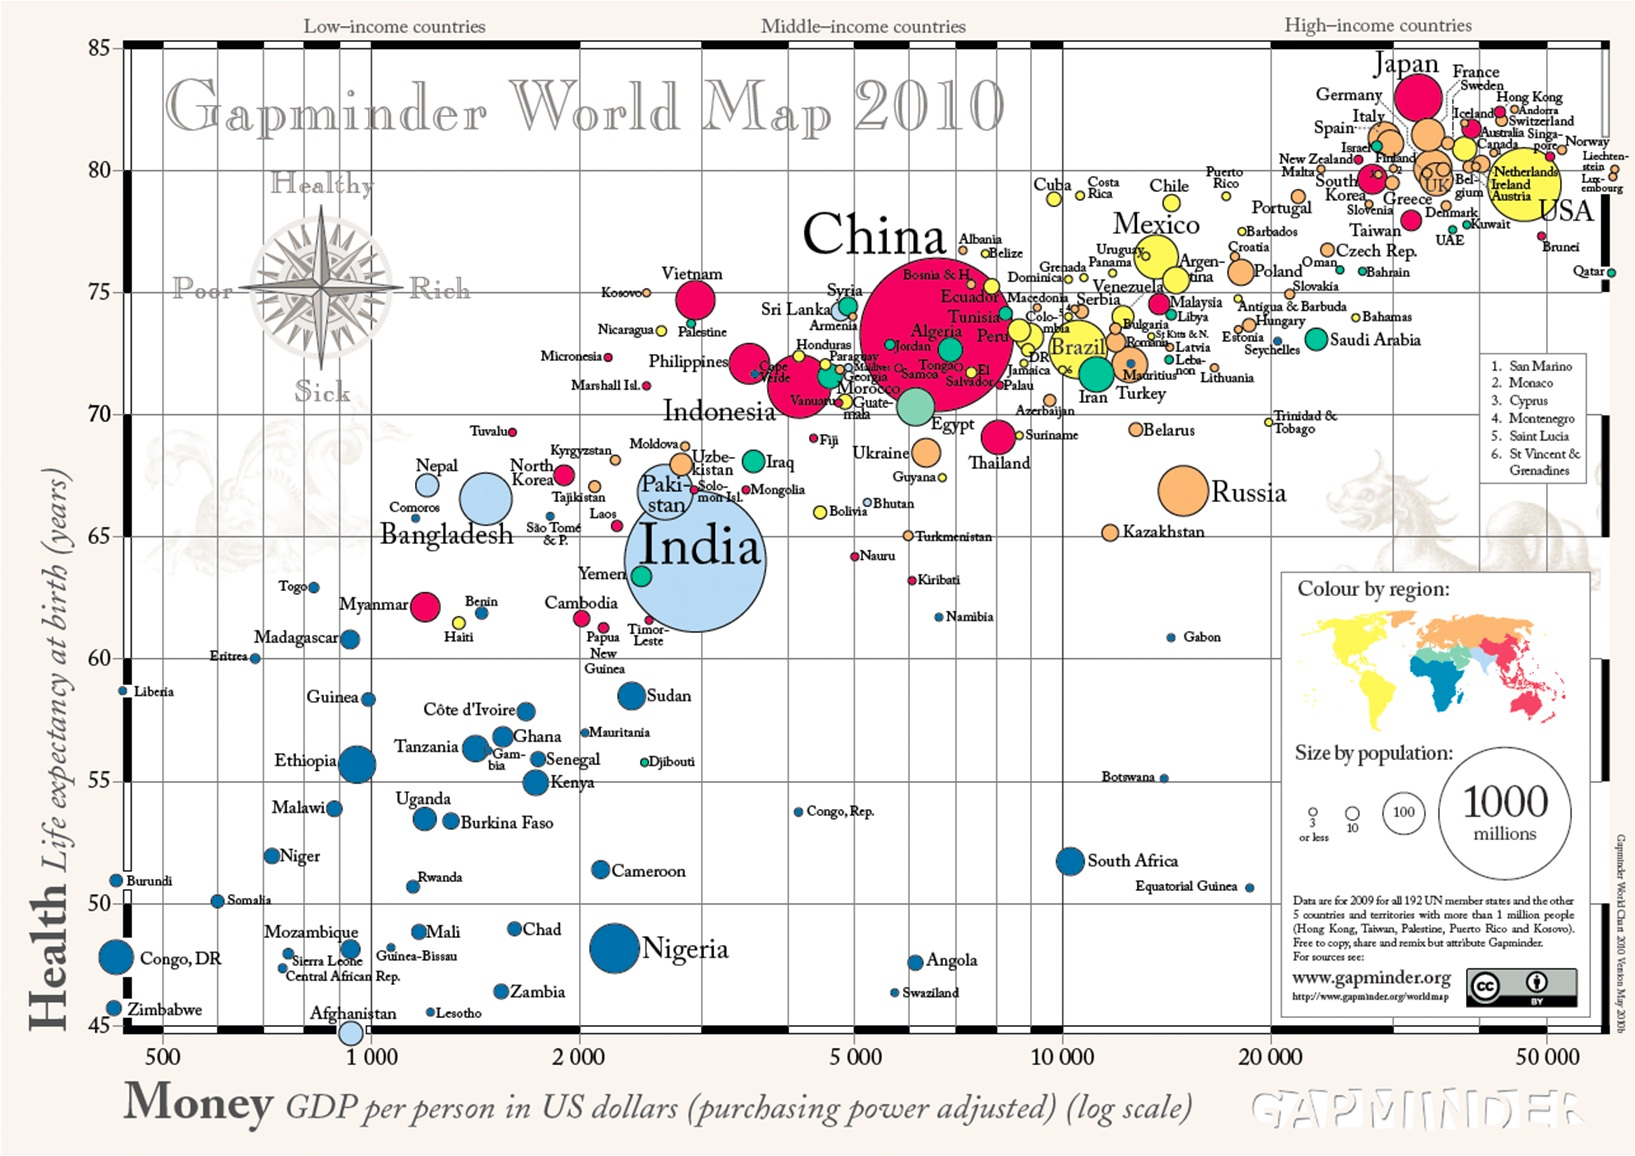





- Correlation between GDP per capita and life expectancy
- The bigger the circle, the larger the population
- Color indicates regions
## ***Fill between***

In [ ]:
x = np.linspace(0, 1, 500)
y = np.sin(4 * np.pi * x) * np.exp(-5 * x)

fig, ax = plt.subplots()

ax.grid(True)
ax.fill(x, y)

In [ ]:
# Line plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

year = [1950, 1970, 1990, 2010]
pop = [2.519, 3.692, 5.263, 6.972]
ax.plot(year, pop)
plt.show()

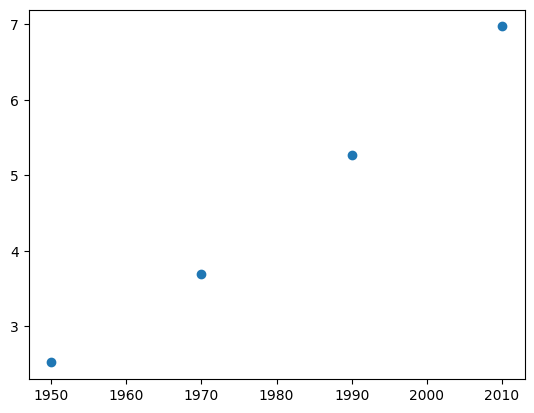

In [ ]:
# Scatter plot
fig, ax = plt.subplots()
ax.scatter(year, pop)
plt.show()

#### ***Exercise: Line plot (1)***

The most basic plot is the **<u>line plot</u>**. A general recipe is given here.

```
import matplotlib.pyplot as plt
plt.plot(x,y)
plt.show()
```
#### ***Instructions***

- `print()` the last item from both the `year` and the `pop` list.

- Use `plt.plot()` to build a line plot. `year` should be mapped on the horizontal axis, `pop` on the vertical axis.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gapminder = pd.read_csv("gapminder.csv").drop(columns='Unnamed: 0')
year, pop = list(np.arange(1950, 2101)), list(np.loadtxt('pop.txt', dtype='float'))
gdp_cap, life_exp, life_exp1950 = list(gapminder['gdp_cap']), list(gapminder['life_exp']), list(np.loadtxt('life.txt', dtype='float'))

# Print the last item from year and pop
print(year[-1])
print(pop[-1])

fig, ax = plt.subplots()
ax.plot(year, pop)
plt.show()

#### ***Exercise: Line Plot (2): Interpretation***

In approximately what year will there be more than ten billion human beings on this planet?

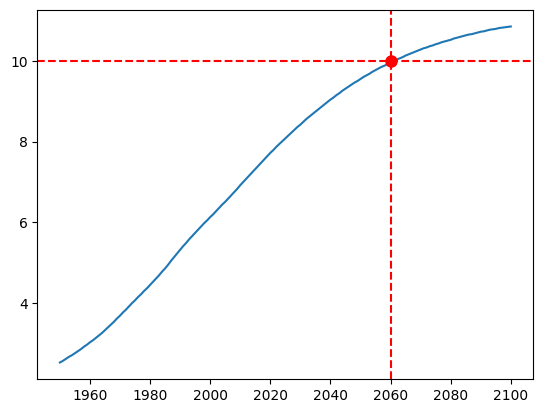

In [ ]:
fig, ax = plt.subplots()

ax.plot(year, pop)
ax.axvline(2060, linestyle='--', color='r')
ax.axhline(10, linestyle='--', color='r')
ax.plot(2060, 10, marker='o', markersize=8, color='red')
plt.show()

#### ***Exercise: Line plot(3)***

- Print the last item from both the list `gdp_cap`, and the list `life_exp`; it is information about Zimbabwe.

- Build a line chart, with `gdp_cap` on the x-axis, and `life_exp` on the y-axis. Does it make sense to plot this data on a line plot?

In [ ]:
# Print the last item of gdp_cap and life_exp
print(gdp_cap[-1])
print(life_exp[-1])

# Make a line plot, gdp_cap on the x-axis, life_exp on the y-axis
fig, ax = plt.subplots()
ax.plot(gdp_cap, life_exp)
plt.show()

This doesn't look right.

#### ***Exercise: Scatter Plot (1)***

When you have a <u>time scale</u> along the horizontal axis, the <u>line plot</u> is your friend. But in many other cases, when you're trying to assess if there's a <u>*correlation between two variables*</u>, the scatter plot is the better choice. Below is an example of how to build a scatter plot.

```
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.show()
```

Let's continue with the `gdp_cap` versus `life_exp` plot, the GDP and life expectancy data for different countries in 2007. Maybe a scatter plot will be a better alternative?


- Change the line plot that's coded in the script to a scatter plot.

- A correlation will become clear when you display the GDP per capita on a logarithmic scale. Add the line **`ax.set_xscale('log')`**.


In [ ]:
fig, ax = plt.subplots()

# Change the line plot below to a scatter plot
ax.scatter(gdp_cap, life_exp)

# Put the x-axis on a logarithmic scale
ax.set_xscale('log')

# Show plot
plt.show()

#### ***Exercise: Scatter plot (2)***

In the above figure, you saw that the higher GDP usually corresponds to a higher life expectancy. In other words, there is a <u>positive correlation</u>.

Do you think there's a relationship between population and life expectancy of a country? The list `life_exp` from the previous exercise is already available. In addition, now also `pop` is available, listing the corresponding populations for the countries in 2007. The populations are in millions of people.


* Build a scatter plot, where `pop` is mapped on the horizontal axis, and `life_exp` is mapped on the vertical axis.


In [ ]:
pop = list(gapminder['population'])

fig, ax = plt.subplots()
ax.scatter(pop, life_exp)
plt.show()

#### ***Exercise: Build a histogram (1)***

```
hist(x, bins=None, range=None, density=False, weights=None,
cumulative=False, bottom=None, histtype='bar', align='mid',
orientation='vertical', rwidth=None, log=False, color=None,
label=None, stacked=False, *, data=None, **kwargs)
```

* `x` is a list of univariate numercial values
* `bins` is the number of bars in histogram (default=10)


To see how life expectancy in different countries is distributed, let's create a histogram of `life_exp`.

Use **`ax.hist()`** to create a histogram of the values in `life_exp`. Do not specify the number of `bins`; Python will set the number of bins to `10` by default for you.

>> I always use the keyword argument `edgecolor='black'` for better picture


In [ ]:
fig, ax = plt.subplots()
ax.hist(life_exp, edgecolor='black')
plt.show()

#### ***Exercise: Build a histogram (2): bins***

In the previous exercise, you didn't specify the number of bins. By default, Python sets the number of bins to 10 in that case. The number of bins is pretty important. Too few bins will oversimplify reality and won't show you the details. Too many bins will overcomplicate reality and won't show the bigger picture.

To control the number of bins to divide your data in, you can set the `bins` argument.

That's exactly what you'll do in this exercise. You'll be making two plots here. The code in the script already includes `plt.show()` and `plt.clf()` calls; `plt.show()` displays a plot; `plt.clf()` cleans it up again so you can start afresh.

>> `plt.clf()` clears the whole figure.  It is better to use `ax.clear()`, which can specifically clear separate axes.

#### ***Instructions***

* Build a histogram of `life_exp`, with 5 bins. Can you tell which bin contains the most observations?
* Build another histogram of `life_exp`, this time with 20 bins. Is this better?

In [ ]:
#### For some reason, writing fig, ax does not show and clear the plots

# Build histogram with 5 bins
plt.hist(life_exp, bins=5, edgecolor='white')

# Show and clean up plot
plt.show()
plt.clf()

# Build histogram with 20 bins
plt.hist(life_exp, bins=20, edgecolor='black')

# Show and clean up again
plt.show()

#### ***Compare histogram***

`life_exp` contains life expectancy data for different countries in 2007. You also have access to a second list now, `life_exp1950`, containing similar data for 1950. Can you make a histogram for both datasets?

* Build a histogram of `life_exp` with 15 bins.
* Build a histogram of `life_exp1950`, also with 15 bins. Is there a big difference with the histogram for the 2007 data?

In [ ]:
# Histogram of life_exp, 15 bins
plt.hist(life_exp, bins=15)

# Show and clear plot
plt.show()
plt.clf()

# Histogram of life_exp1950, 15 bins
plt.hist(life_exp1950, bins=15)

# Show and clear plot again
plt.show()
plt.clf()

#### ***Horizontal back-to-back histogram***

- Using **`np.histogram`** allows you to place two histograms in the opposite direction

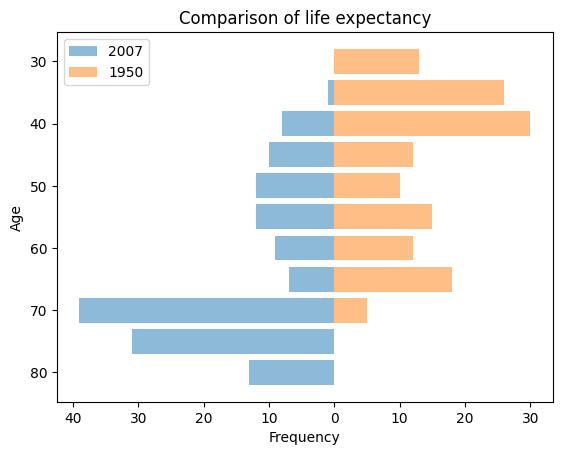

In [ ]:
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from matplotlib.ticker import FuncFormatter

gapminder = pd.read_csv("gapminder.csv").drop(columns='Unnamed: 0')
year, pop = list(np.arange(1950, 2101)), list(np.loadtxt('pop.txt', dtype='float'))
gdp_cap, life_exp, life_exp1950 = list(gapminder['gdp_cap']), list(gapminder['life_exp']), list(np.loadtxt('life.txt', dtype='float'))

bins = np.arange(30, 90, 5)
fig, ax = plt.subplots()

# Plot the first histogram
ax.barh(bins[:-1], -np.histogram(life_exp, bins=bins)[0], height=4, alpha=0.5, label='2007')

# Plot the second histogram
ax.barh(bins[:-1], np.histogram(life_exp1950, bins=bins)[0], height=4, alpha=0.5, label='1950')

# Add labels and title
ax.set_xlabel('Frequency')
ax.set_ylabel('Age')
ax.set_title('Comparison of life expectancy')
ax.legend()

# Invert y-axis to have bars pointing in the correct direction
ax.invert_yaxis()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{abs(int(x))}'))

# Show the plot
plt.show()

# ***Customizimg Plot***

## ***Axis Labels, Titles, Ticks***



In [ ]:
gapminder = pd.read_csv("gapminder.csv").drop(columns='Unnamed: 0')
year, pop = list(np.arange(1950, 2101)), list(np.loadtxt('pop.txt', dtype='float'))
gdp_cap, life_exp, life_exp1950 = list(gapminder['gdp_cap']), list(gapminder['life_exp']), list(np.loadtxt('life.txt', dtype='float'))

fig, ax = plt.subplots()
ax.plot(year, pop)
ax.set_xlabel('Year')
ax.set_ylabel('Population')
ax.set_title('World Population Projections')
ax.set_yticks([0, 2, 4, 6, 8, 10],
              ['0', '2B', '4B', '6B', '8B', '10B'])
plt.show()


## ***Adding Historical data***

In [ ]:
# Add more data
year = [1800, 1850, 1900] + year
pop = [1.0, 1.262, 1.650] + pop
fig, ax = plt.subplots()
ax.plot(year, pop)
ax.set_xlabel('Year')
ax.set_ylabel('Population')
ax.set_title('World Population Projections')
ax.set_yticks([0, 2, 4, 6, 8, 10],
              ['0', '2B', '4B', '6B', '8B', '10B'])
plt.show()

#### ***Exercise: Labels***

You're going to work on the scatter plot with world development data: GDP per capita on the x-axis (logarithmic scale), life expectancy on the y-axis.

#### ***Instructions***

- The strings `xlab` and `ylab` are already set for you. Use these variables to set the label of the x- and y-axis.
- The string `title` is also coded for you. Use it to add a title to the plot.
- After these customizations, finish the script with `plt.show()` to actually display the plot.

In [ ]:
gapminder = pd.read_csv("gapminder.csv").drop(columns='Unnamed: 0')
year, pop = list(np.arange(1950, 2101)), list(np.loadtxt('pop.txt', dtype='float'))
gdp_cap, life_exp, life_exp1950 = list(gapminder['gdp_cap']), list(gapminder['life_exp']), list(np.loadtxt('life.txt', dtype='float'))

fig, ax = plt.subplots()
xlab = 'GDP per Capita [in USD]'
ylab = 'Life Expectancy [in years]'
title = 'World Development in 2007'

# Basic scatter plot, log scale
ax.scatter(gdp_cap, life_exp)
ax.set_xscale('log')
plt.show()


#### ***Exercise: Ticks***

The customizations you've coded up to now are available in the script, in a more concise form.

How you could control the y-ticks by specifying two arguments:

`plt.yticks([0,1,2], ["one","two","three"])`

In this example, the ticks corresponding to the numbers 0, 1 and 2 will be replaced by one, two and three, respectively.

Let's do a similar thing for the x-axis of your world development chart, with the `set_xticks()` function. The tick values 1000, 10000 and 100000 should be replaced by 1k, 10k and 100k. To this end, two lists have already been created for you: `tick_val` and `tick_lab`.

#### ***Instructions***

- Use `tick_val` and `tick_lab` as inputs to the `set_xticks()` function to make the the plot more readable.
- As usual, display the plot with `plt.show()` after you've added the customizations.

In [ ]:
fig, ax = plt.subplots()

# Scatter plot
ax.scatter(gdp_cap, life_exp)

# Previous customizations
ax.set_xscale('log')
ax.set_xlabel('GDP per Capita [in USD]')
ax.set_ylabel('Life Expectancy [in years]')
ax.set_title('World Development in 2007')

# Definition of tick_val and tick_lab
tick_val = [1000, 10000, 100000]
tick_lab = ['1k', '10k', '100k']

# Adapt the ticks on the x-axis
ax.set_xticks(tick_val, tick_lab)
plt.show()


#### ***Exercise: Sizes***

Right now, the scatter plot is just a cloud of blue dots, indistinguishable from each other. Let's change this. Wouldn't it be nice <u>***if the size of the dots corresponds to the population?***</u>

To accomplish this, there is a list `pop` loaded in your workspace. It contains population numbers for each country expressed in millions. You can see that this list is added to the `scatter` method, as the argument `s`, for size.

#### ***Instructions***

- Run the script to see how the plot changes.
- Looks good, but increasing the size of the bubbles will make things stand out more.
  - Import the numpy package as np.
  * Use **`np.array()`** to create a numpy array from the list `pop`. Call this NumPy array `np_pop`.
  * Double the values in `np_pop` setting the value of `np_pop` equal to `np_pop * 2`. Because `np_pop` is a NumPy array, each array element will be doubled.
  * Change the **`s`** argument inside **`ax.scatter()`** to be `np_pop` instead of `pop`

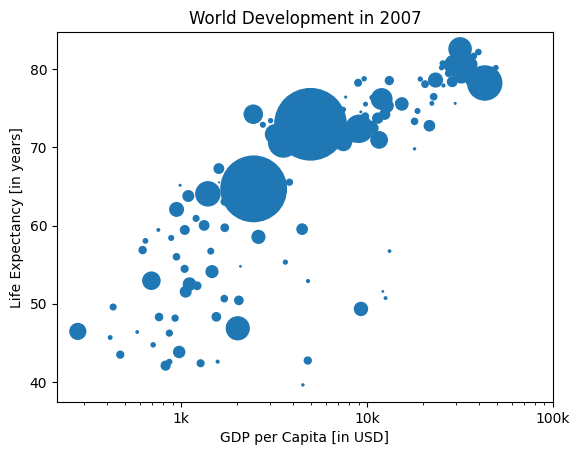

In [ ]:
import matplotlib.pyplot as plt, numpy as np, pandas as pd

gapminder = pd.read_csv("gapminder.csv").drop(columns='Unnamed: 0')
pop = list(np.array(gapminder['population'])/10e5)
gdp_cap, life_exp, life_exp1950 = list(gapminder['gdp_cap']), list(gapminder['life_exp']), list(np.loadtxt('life.txt', dtype='float'))

fig, ax = plt.subplots()

np_pop = np.array(pop)
np_pop *= 2


# Update: set s argument to np_pop
ax.scatter(gdp_cap, life_exp, s=np_pop)

# Previous customizations
ax.set_xscale('log')
ax.set_xlabel('GDP per Capita [in USD]')
ax.set_ylabel('Life Expectancy [in years]')
ax.set_title('World Development in 2007')
ax.set_xticks([1000, 10000, 100000],['1k', '10k', '100k'])
plt.show()


#### ***Exercise: Colors***

The next step is making the plot more colorful! To do this, a list `col` has been created for you. It's a list with a color for each corresponding country, depending on the continent the country is part of.

How did we make the list `col` you ask? The Gapminder data contains a list continent with the continent each country belongs to. A dictionary is constructed that maps continents onto colors:


```
dict = {'Asia':'red',
        'Europe':'green',
        'Africa':'blue',
        'Americas':'yellow',
        'Oceania':'black'}
```



#### ***Instructions***

- Add `c=col` to the arguments of the **`ax.scatter()`** function.
- Change the opacity of the bubbles by setting the `alpha` argument to `0.8` inside **`ax.scatter()`**. Alpha can be set from zero to one, where zero is totally transparent, and one is not at all transparent.

In [ ]:
color_dict = {'Asia':'red',
              'Europe':'green',
              'Africa':'blue',
              'Americas':'yellow',
              'Oceania':'black'}

gapminder['color'] = gapminder['cont'].map(color_dict)
col = list(gapminder['color'])

fig, ax = plt.subplots()

# Specify c and alpha inside plt.scatter()
ax.scatter(x=gdp_cap, y=life_exp, s=np.array(pop)*2, c=col, alpha=0.8)

# Previous customizations
ax.set_xscale('log')
ax.set_xlabel('GDP per Capita [in USD]')
ax.set_ylabel('Life Expectancy [in years]')
ax.set_title('World Development in 2007')
ax.set_xticks([1000,10000,100000], ['1k','10k','100k'])

# Show the plot
plt.show()

#### ***Exercise: Additional Customizations***

If you have another look at the script, under *# Additional Customizations*, you'll see that there are two `ax.text()` functions now. They add the words `"India"` and `"China"` in the plot.

#### ***Instructions***

- Add `ax.grid(True)` after the ax.text() calls so that gridlines are drawn on the plot.

In [ ]:
fig, ax = plt.subplots()

# Specify c and alpha inside plt.scatter()
ax.scatter(x=gdp_cap, y=life_exp, s=np.array(pop)*2, c=col, alpha=0.8)

# Previous customizations
ax.set_xscale('log')
ax.set_xlabel('GDP per Capita [in USD]')
ax.set_ylabel('Life Expectancy [in years]')
ax.set_title('World Development in 2007')
ax.set_xticks([1000,10000,100000], ['1k','10k','100k'])

# Additional customizations
ax.text(1550, 71, 'India')
ax.text(5700, 80, 'China')

# Create legend
legend_handles = []
for continent, color in color_dict.items():
    handle = plt.Line2D([], [], marker='o', color='w', markerfacecolor=color, label=continent)
    legend_handles.append(handle)

ax.legend(handles=legend_handles, title='Continent')
ax.grid(True)

# Show the plot
plt.show()

***Interpretation***

If you have a look at your colorful plot, it's clear that people live longer in countries with a higher GDP per capita. No high income countries have really short life expectancy, and no low income countries have very long life expectancy. Still, there is a huge difference in life expectancy between countries on the same income level. Most people live in middle income countries where difference in lifespan is huge between countries; depending on how income is distributed and how it is used.   The countries in blue, corresponding to Africa, have both low life expectancy and a low GDP per capita.

# ***Data Plotting***

We should learn a bit more about plotting from data.  We'll learn more in EDA part.

## **Histograms**

- Used to see univariate distribution of the numerical data

In [ ]:
import matplotlib.pyplot as plt, pandas as pd

df = pd.read_csv('homelessness.csv', index_col=[0])
df['individuals'].hist(bins=50, edgecolor='black')
plt.title('Homeless')
plt.show()

You can do the same thing with `matplotlib`

In [ ]:
fig, ax = plt.subplots(2, 1)
ax[0].hist(df['individuals'], bins=50, edgecolor='black')
ax[0].set_title('Homeless')
ax[1].hist(df['individuals'], bins=10, edgecolor='black')
ax[1].set_title('Homeless')
plt.show()

## **Bar plots**

- Generally display relationship between a categorical variable and a numerical variable.

In [ ]:
df2 = df.groupby('region')['individuals'].mean()
df2 = df2.sort_values(ascending=False)
display(df2)
df2.plot(kind='bar', edgecolor='black', title='homeless by region')
plt.show()

Again, you can do the same thing by matplotlib, but bar plot has a little more cumbersome syntax.


In [ ]:
fig, ax = plt.subplots()
ax.bar(df2.index, df2, edgecolor='black')
ax.set_title('homeless')
ax.tick_params(axis='x', labelrotation=90)
plt.show()

## **Line plot**

- Used when variables on the horizontal axis have meaningful connection to their values.
   -  E.g., Time has connection to each of its values.

In [ ]:
sales = pd.read_csv('sales_subset.csv', index_col=[0], parse_dates=['date'])
sales_1 = sales.loc[sales['store']==1]
sales_1 = sales_1.sort_values('date')
sales_1.plot(x='date', y='unemployment')
plt.show()

## ***Scatter Plot***

- Used when displaying relationship bewtween 2 numerical variables
- Can extend up to 4 variables by some more techniques

In [ ]:
sales.plot(x='temperature_c', y='fuel_price_usd_per_l', kind='scatter')
plt.show()

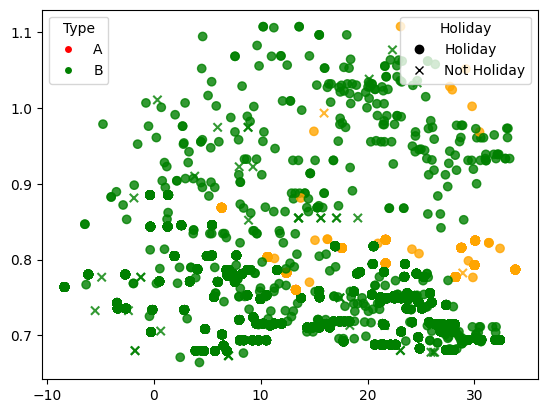

In [6]:
# A more complicated demonstration
fig, ax = plt.subplots()

color_dict = {'A':'green',
              'B':'orange'}

sales['color'] = sales['type'].map(color_dict)

markers = {True: 'x', False: 'o'}
sales['marker'] = sales['is_holiday'].map(markers)

for holiday, marker in markers.items():
    data = sales[sales['is_holiday'] == holiday]

    ax.scatter(
        x=data['temperature_c'],
        y=data['fuel_price_usd_per_l'],
        c=data['color'],
        marker=marker,
        alpha=0.8
    )
# Legend: color
from matplotlib.lines import Line2D

color_legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', label='A'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', label='B')
]

# Legend: marker
marker_legend = [
    Line2D([0], [0], marker='o', color='black',
           linestyle='None', label='Holiday'),
    Line2D([0], [0], marker='x', color='black',
           linestyle='None', label='Not Holiday')
]

legend1 = ax.legend(handles=color_legend, title='Type',
                    loc='upper left')
ax.add_artist(legend1)

ax.legend(handles=marker_legend, title='Holiday',
          loc='upper right')

plt.show()

Doing this using matplotlib is complicated.  Another package called **`seaborn`** can do this in one line.

>> Unfortunately **`seaborn`** is rarely taught in academia.  You are on your own to learn that.

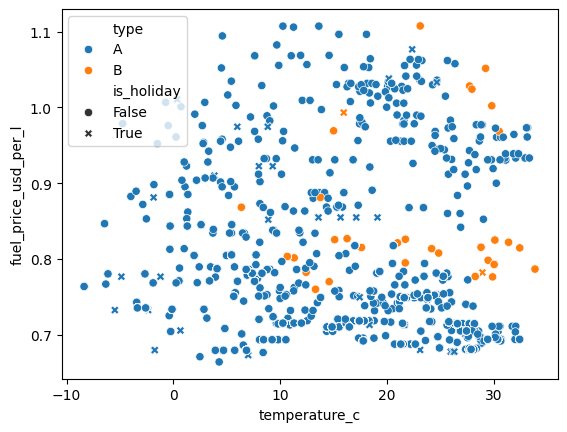

In [4]:
from seaborn import scatterplot

scatterplot(data=sales, x='temperature_c', y='fuel_price_usd_per_l', hue='type', style='is_holiday')
plt.show()

## ***Layering plots***

In [ ]:
sales[sales['type']=='A']['temperature_c'].hist(bins=30, edgecolor='black', alpha=0.7)
sales[sales['type']=='B']['temperature_c'].hist(bins=30, edgecolor='black', alpha=0.7)
plt.legend(['A', 'B'])
plt.show()

#### ***Exercise Bar Plot: Which avocado size is most popular?***

Bar plots are great for revealing <u>***relationships between categorical and numeric variables***</u>, but you'll often have to manipulate your data first in order to get the numbers you need for plotting.

#### ***Instructions***

* Print the head of the `avocados` dataset. What columns are available?
* For each avocado size group, calculate the total number sold, storing as `nb_sold_by_size`.
* Create a bar plot of the number of avocados sold by size.
* Show the plot.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

avocados = pd.read_pickle("avoplotto.pkl")

# Look at the first few rows of data
display(avocados.head())

# Get the total number of avocados sold of each size
nb_sold_by_size = avocados.groupby("size")["nb_sold"].sum()

# Create a bar plot of the number of avocados sold by size
fig, ax = plt.subplots()
nb_sold_by_size.plot(kind="bar", ax=ax)
ax.set_ylabel("Number Sold")
plt.show()

#### ***Exercise Line Plot: Changes in sales over time***

Line plots are designed to visualize the relationship between two numeric variables, where each data values is connected to the next one. They are especially useful for <ins>***visualizing the change in a number over time***</ins> since each time point is naturally connected to the next time point.

#### ***Instructions***

* Get the total number of avocados sold on each date. *The DataFrame has two rows for each date -- one for organic, and one for conventional.* Save this as `nb_sold_by_date`.
* Create a line plot of the number of avocados sold.
* Show the plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

avocados = pd.read_pickle("avoplotto.pkl")

# Get the total number of avocados sold on each date
nb_sold_by_date = avocados.groupby("date")["nb_sold"].sum()

# Create a line plot of the number of avocados sold by date
fig, ax = plt.subplots()
nb_sold_by_date.plot(x="date", y="nb_sold", kind="line", rot=45, ax=ax)
ax.set_ylabel("Number sold")
plt.show()

#### ***Exercise Scatter Plot: Avocado supply and demand***

Scatter plots are ideal for visualizing relationships between numerical variables. In this exercise, you'll compare the number of avocados sold to average price and see if they're at all related. If they're related, you may be able to use one number to predict the other.


#### ***Instructions***

* Create a scatter plot with `nb_sold` on the x-axis and `avg_price` on the y-axis. Title it `"Number of avocados sold vs. average price"`.
* Show the plot.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

avocados = pd.read_pickle("avoplotto.pkl")

# Scatter plot of nb_sold vs avg_price with title
fig, ax = plt.subplots()
avocados.plot(x="nb_sold", y="avg_price", kind="scatter", title="Number of avocados sold vs. average price", ax=ax)
plt.show()

### ***Exercise Histograms: Price of conventional vs. organic avocados***

Creating multiple plots for different subsets of data allows you to compare groups. In this exercise, you'll create multiple histograms to compare the prices of conventional and organic avocados.

#### ***Instructions***

* Subset `avocados` for the conventional type, and the average price column. Create a histogram.
* Create a histogram of `avg_price` for organic type avocados.
* Add a legend to your plot, with the names "conventional" and "organic".
* Show your plot.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

avocados = pd.read_pickle("avoplotto.pkl")

# Histogram of conventional avg_price
avocados[avocados["type"]=="conventional"]["avg_price"].hist(alpha=0.5, bins=20)

# Histogram of organic avg_price
avocados[avocados["type"]=="organic"]["avg_price"].hist(alpha=0.5, bins=20)

# Add a legend
plt.legend(["conventional", "organic"])

# Show the plot
plt.show()

>> From here on it will be a formal treatment on **`matplotlib`**.

>> - This is getting old. Whether this will be taught in class depends on how much time we have left in each semester. Even if it is taught it will be covered relatively quick.

# **Introduction to pyplot interface**

* Always start with **`plt.subplots()`** which create `fig` and `ax` objects.

## **Addig data to axes**

In [ ]:
seattle_weather = pd.read_csv("seattle_weather.csv")
seattle_weather['DATE'] = seattle_weather['DATE'].map({1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'})
seattle_weather.rename(columns={'DATE':'MONTH'}, inplace=True)
seattle_weather = seattle_weather[['MONTH', 'MLY-TAVG-NORMAL']].head(12)

fig, ax = plt.subplots()
ax.plot(seattle_weather['MONTH'], seattle_weather['MLY-TAVG-NORMAL'])
plt.show()

In [ ]:
import matplotlib.pyplot as plt, pandas as pd, numpy as np
import ipywidgets as widgets
from IPython.display import display

fig, ax = plt.subplots()

In [ ]:
seattle_weather = pd.read_csv('seattle_weather.csv')
austin_weather = pd.read_csv('austin_weather.csv')
austin_weather['DATE'] = austin_weather['DATE'].map({1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'})
seattle_weather['DATE'] = seattle_weather['DATE'].map({1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'})
seattle_weather.rename(columns={'DATE':'MONTH'}, inplace=True)
austin_weather.rename(columns={'DATE':'MONTH'}, inplace=True)
df = seattle_weather[['MONTH', 'MLY-TAVG-NORMAL']].head(12)
df2 = austin_weather[['MONTH', 'MLY-TAVG-NORMAL']].head(12)
df

,MONTH,MLY-TAVG-NORMAL
0,Jan,39.3
1,Feb,40.7
2,Mar,43.8
3,Apr,47.4
4,May,53.1
5,Jun,57.8
6,Jul,62.9
7,Aug,63.5
8,Sep,58.9
9,Oct,50.7


In [ ]:
fig, ax = plt.subplots()
ax.plot(df['MONTH'], df['MLY-TAVG-NORMAL'])
plt.show()

## **Plotting data**

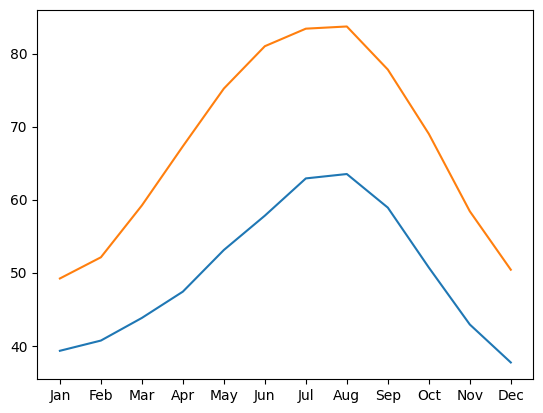

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['MONTH'], df['MLY-TAVG-NORMAL'])
ax.plot(df2['MONTH'], df2['MLY-TAVG-NORMAL'])
plt.show()

#### ***Exercise: Using the `matplotlib.pyplot` interface***

There are many ways to use Matplotlib. In this course, we will focus on the **`pyplot`** interface, which provides the most flexibility in creating and customizing data visualizations.

Initially, we will use the **`pyplot`** interface to create two kinds of objects: **Figure** objects and **bold text**Axes objects.

This course introduces a lot of new concepts, so if you ever need a quick refresher, download the [Matplotlib Cheat Sheet](https://datacamp-community-prod.s3.amazonaws.com/28b8210c-60cc-4f13-b0b4-5b4f2ad4790b) and keep it handy!

* Import the **`matplotlib.pyplot`** API, using the conventional name **`plt`**.
* Create Figure and Axes objects using the **`plt.subplots`** function.
* Show the results, an empty set of axes, using the **`plt.show`** function.

In [ ]:
# Import the matplotlib.pyplot submodule and name it plt
import matplotlib.pyplot as plt

# Create a Figure and an Axes with plt.subplots
fig, ax = plt.subplots()

# Call the show function to show the result
plt.show()

#### ***Exercise: Adding data to an Axes object***

Adding data to a figure is done by calling methods of the **Axes** object. In this exercise, we will use the **`plot`** method to add data about rainfall in two American cities: Seattle, WA and Austin, TX.

The data are stored in two Pandas DataFrame objects that are already loaded into memory: `seattle_weather` stores information about the weather in Seattle, and `austin_weather` stores information about the weather in Austin. Each of the data frames has a `"MONTH"` column that stores the three-letter name of the months. Each also has a column named `"MLY-PRCP-NORMAL"` that stores the average rainfall in each month during a ten-year period.

In this exercise, you will create a visualization that will allow you to compare the rainfall in these two cities.

* Create a **Figure** and an **Axes** object by calling **`plt.subplots`**.
* Add data from the `seattle_weather` DataFrame by calling the **Axes** plot method.
* Add data from the `austin_weather` DataFrame in a similar manner and call **`plt.show`** to show the results.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

seattle_weather = pd.read_csv('seattle_weather.csv').iloc[:12]
austin_weather = pd.read_csv('austin_weather.csv').iloc[:12]
month = {1: 'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
seattle_weather['MONTH'] = seattle_weather['DATE'].map(month)
austin_weather['MONTH'] = austin_weather['DATE'].map(month)

# Create a Figure and an Axes with plt.subplots
fig, ax = plt.subplots()

# Plot MLY-PRCP-NORMAL from seattle_weather against the MONTH
ax.plot(seattle_weather['MONTH'], seattle_weather['MLY-PRCP-NORMAL'])

# Plot MLY-PRCP-NORMAL from austin_weather against MONTH
ax.plot(austin_weather['MONTH'], austin_weather['MLY-PRCP-NORMAL'])

# Call the show function
plt.show()

# **Customizing your plots**

## **Adding markers**

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['MONTH'], df['MLY-TAVG-NORMAL'], marker='o')
plt.show()

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['MONTH'], df['MLY-TAVG-NORMAL'], marker='v')
plt.show()

## **Setting the linestyle**

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['MONTH'], df['MLY-TAVG-NORMAL'], marker='o', linestyle='--')
plt.show()

## **Disable line**

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['MONTH'], df['MLY-TAVG-NORMAL'], marker='o', linestyle='None')
plt.show()

## **Choosing color**

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['MONTH'], df['MLY-TAVG-NORMAL'], marker='v', linestyle='--', color='r')
plt.show()

## **Customizing Axes Labels**

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['MONTH'], df['MLY-TAVG-NORMAL'], marker='o', linestyle='--', color='r')
ax.set_xlabel('Time (months)')
ax.set_ylabel("Average temperature (Fahrenheit degrees)")
plt.show()

## **Adding a title**

In [ ]:
fig, ax = plt.subplots()
ax.plot(df['MONTH'], df['MLY-TAVG-NORMAL'], marker='o', linestyle='--', color='r')
ax.set_xlabel('Time (months)')
ax.set_ylabel("Average temperature (Fahrenheit degrees)")
ax.set_title('Weather in Seattle')
plt.show()

## ***Markers***

https://matplotlib.org/api/markers_api.html

- Note that marker does not support array type input

In [ ]:
fig, ax = plt.subplots()
ax.plot(seattle_weather['MONTH'], seattle_weather['MLY-PRCP-NORMAL'], marker='o')
plt.show()

In [ ]:
fig, ax = plt.subplots()
ax.plot(seattle_weather['MONTH'], seattle_weather['MLY-PRCP-NORMAL'], marker='v')
plt.show()

## ***Linestyle***

https://matplotlib.org/gallery/lines_bars_and_markers/line_styles_reference.html

In [ ]:
fig, ax = plt.subplots()
ax.plot(seattle_weather["MONTH"], seattle_weather["MLY-TAVG-NORMAL"], marker="v", linestyle="None")
plt.show()

In [ ]:
fig, ax = plt.subplots()
ax.plot(seattle_weather["MONTH"], seattle_weather["MLY-TAVG-NORMAL"], marker="o", linestyle="--")
plt.show()

## ***Color***

In [ ]:
fig, ax = plt.subplots()
ax.plot(seattle_weather["MONTH"], seattle_weather["MLY-TAVG-NORMAL"], marker="v", linestyle="--", color="r")
plt.show()

## ***Axes labels and title***

In [ ]:
fig, ax = plt.subplots()
ax.plot(seattle_weather["MONTH"], seattle_weather["MLY-TAVG-NORMAL"],marker="v", linestyle="--", color="r")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Average temperature (Fahrenheit degrees)")
ax.set_title("Weather in Seattle")
plt.show()

#### ***Exercise: Customizing data appearance***

We can customize the appearance of data in our plots, while adding the data to the plot, using key-word arguments to the `plot` command.

In this exercise, you will customize the appearance of the `marker`s, the `linestyle` that is used, and the `color` of the lines and markers for your data.

As before, the data is already provided in Pandas DataFrame objects loaded into memory: `seattle_weather` and `austin_weather`. These each have a `"MONTHS"` column and a `"MLY-PRCP-NORMAL"` that you will plot against each other.

* Call `plt.plot` to plot `"MLY-PRCP-NORMAL"` against `"MONTHS"` in both DataFrames.
* Pass the `color` key-word arguments to these commands to set the color of the Seattle data to blue (`'b'`) and the Austin data to red (`'r'`).
* Pass the `marker` key-word arguments to these commands to set the Seattle data to circle markers (`'o'`) and the Austin markers to triangles pointing downwards (`'v'`).
* Pass the `linestyle` key-word argument to use dashed lines for the data from both cities (`'--'`).

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

seattle_weather = pd.read_csv('seattle_weather.csv').iloc[:12]
austin_weather = pd.read_csv('austin_weather.csv').iloc[:12]
month = {1: 'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
seattle_weather['MONTH'] = seattle_weather['DATE'].map(month)
austin_weather['MONTH'] = austin_weather['DATE'].map(month)

fig, ax = plt.subplots()

# Plot Seattle data, setting data appearance
ax.plot(seattle_weather["MONTH"], seattle_weather["MLY-PRCP-NORMAL"], color='b', marker='o', linestyle='--')

# Plot Austin data, setting data appearance
ax.plot(austin_weather["MONTH"], austin_weather["MLY-PRCP-NORMAL"], color='r', marker='v', linestyle='--')

# Call show to display the resulting plot
plt.show()

#### ***Exercise: Customizing axis labels and adding titles***

Customizing the axis labels requires using the `set_xlabel` and `set_ylabel` methods of the **Axes** object. Adding a title uses the `set_title` method.

* Use the `set_xlabel` method to add the label: `"Time (months)"`.
* Use the `set_ylabel` method to add the label: `"Precipitation (inches)"`.
* Use the `set_title` method to add the title: `"Weather patterns in Austin and Seattle"`.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

seattle_weather = pd.read_csv('seattle_weather.csv').iloc[:12]
austin_weather = pd.read_csv('austin_weather.csv').iloc[:12]
month = {1: 'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
seattle_weather['MONTH'] = seattle_weather['DATE'].map(month)
austin_weather['MONTH'] = austin_weather['DATE'].map(month)

fig, ax = plt.subplots()

ax.plot(seattle_weather["MONTH"], seattle_weather["MLY-PRCP-NORMAL"])
ax.plot(austin_weather["MONTH"], austin_weather["MLY-PRCP-NORMAL"])

# Customize the x-axis label
ax.set_xlabel('Time (months)')

# Customize the y-axis label
ax.set_ylabel('Precipitation (inches)')

# Add the title
ax.set_title('Weather patterns in Austin and Seattle')

# Display the figure
plt.show()

# **Small Multiples**

## **Too many data**

In [ ]:
df["MLY-PRCP-NORMAL"], df["MLY-PRCP-25PCTL"], df["MLY-PRCP-75PCTL"] = seattle_weather["MLY-PRCP-NORMAL"].head(12), seattle_weather["MLY-PRCP-25PCTL"].head(12), seattle_weather['MLY-PRCP-75PCTL'].head(12)
df2["MLY-PRCP-NORMAL"], df2["MLY-PRCP-25PCTL"], df2["MLY-PRCP-75PCTL"] = austin_weather["MLY-PRCP-NORMAL"].head(12), austin_weather["MLY-PRCP-25PCTL"].head(12), austin_weather['MLY-PRCP-75PCTL'].head(12)

fig, ax = plt.subplots()
ax.plot(df["MONTH"], df["MLY-PRCP-NORMAL"], color='b')
ax.plot(df["MONTH"], df["MLY-PRCP-25PCTL"], linestyle='--', color='b')
ax.plot(df["MONTH"], df["MLY-PRCP-75PCTL"], linestyle='--', color='b')

ax.plot(df2["MONTH"], df2["MLY-PRCP-NORMAL"], color='r')
ax.plot(df2["MONTH"], df2["MLY-PRCP-25PCTL"], linestyle='--', color='r')
ax.plot(df2["MONTH"], df2["MLY-PRCP-75PCTL"], linestyle='--', color='r')
ax.set_xlabel("Time (months)")
ax.set_ylabel("Precipitation (inches)")
plt.show()

## **Small multiples with plt.subplots**

In [ ]:
fig, ax = plt.subplots(2, 1)

ax[0].plot(df["MONTH"], df["MLY-PRCP-NORMAL"], color='b')
ax[0].plot(df["MONTH"], df["MLY-PRCP-25PCTL"], linestyle='--', color='b')
ax[0].plot(df["MONTH"], df["MLY-PRCP-75PCTL"], linestyle='--', color='b')

ax[1].plot(df2["MONTH"], df2["MLY-PRCP-NORMAL"], color='r')
ax[1].plot(df2["MONTH"], df2["MLY-PRCP-25PCTL"], linestyle='--', color='r')
ax[1].plot(df2["MONTH"], df2["MLY-PRCP-75PCTL"], linestyle='--', color='r')
ax[0].set_xlabel("Time (months)")
ax[0].set_ylabel("Precipitation (inches)")
ax[1].set_xlabel("Time (months)")
ax[1].set_ylabel("Precipitation (inches)")
plt.show()

## ***Sharing the y-axis range***

Both subplots will have the same range of y-axis.

- We'll use this pretty often

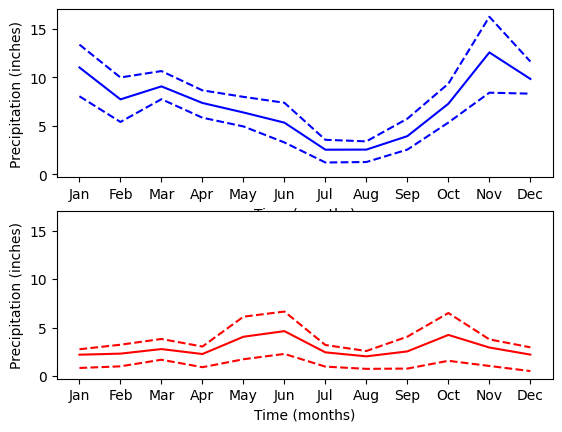

In [ ]:
fig, ax = plt.subplots(2, 1, sharey=True)
ax[0].plot(df["MONTH"], df["MLY-PRCP-NORMAL"], color='b')
ax[0].plot(df["MONTH"], df["MLY-PRCP-25PCTL"], linestyle='--', color='b')
ax[0].plot(df["MONTH"], df["MLY-PRCP-75PCTL"], linestyle='--', color='b')

ax[1].plot(df2["MONTH"], df2["MLY-PRCP-NORMAL"], color='r')
ax[1].plot(df2["MONTH"], df2["MLY-PRCP-25PCTL"], linestyle='--', color='r')
ax[1].plot(df2["MONTH"], df2["MLY-PRCP-75PCTL"], linestyle='--', color='r')
ax[0].set_xlabel("Time (months)")
ax[0].set_ylabel("Precipitation (inches)")
ax[1].set_xlabel("Time (months)")
ax[1].set_ylabel("Precipitation (inches)")
plt.show()

#### ***Excercise: Creating small multiples with `plt.subplots`***

Small multiples are used to plot several datasets side-by-side. In Matplotlib, small multiples can be created using the **`plt.subplots()`** function. The first argument is the number of rows in the array of **Axes** objects generate and the second argument is the number of columns. In this exercise, you will use the Austin and Seattle data to practice creating and populating an array of subplots.

The data is given to you in DataFrames: `seattle_weather` and `austin_weather`. Each have a `"MONTH"` column and `"MLY-PRCP-NORMAL"` (for average precipitation), as well as `"MLY-TAVG-NORMAL"` (for average temperature) columns. In this exercise, you will plot in a separate subplot the monthly average precipitation and average temperatures in each city.

* Create a Figure and an array of subplots with 2 rows and 2 columns.
* Addressing the top left Axes as index `0`, `0`, plot the Seattle precipitation.
* In the top right (index `0`,`1`), plot Seattle temperatures.
* In the bottom left (`1`, `0`) and bottom right (`1`, `1`) plot Austin precipitations and temperatures.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

seattle_weather = pd.read_csv('seattle_weather.csv').iloc[:12]
austin_weather = pd.read_csv('austin_weather.csv').iloc[:12]
month = {1: 'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
seattle_weather['MONTH'] = seattle_weather['DATE'].map(month)
austin_weather['MONTH'] = austin_weather['DATE'].map(month)

# Create a Figure and an array of subplots with 2 rows and 2 columns
fig, ax = plt.subplots(2, 2, figsize=(16, 8))

# Addressing the top left Axes as index 0, 0, plot month and Seattle precipitation
ax[0, 0].plot(seattle_weather['MONTH'], seattle_weather['MLY-PRCP-NORMAL'])

# In the top right (index 0,1), plot month and Seattle temperatures
ax[0, 1].plot(seattle_weather['MONTH'], seattle_weather['MLY-TAVG-NORMAL'])

# In the bottom left (1, 0) plot month and Austin precipitations
ax[1, 0].plot(austin_weather['MONTH'], austin_weather['MLY-PRCP-NORMAL'])

# In the bottom right (1, 1) plot month and Austin temperatures
ax[1, 1].plot(austin_weather['MONTH'], austin_weather['MLY-TAVG-NORMAL'])
plt.show()

### ***Small multiples with shared y axis***

When creating small multiples, it is often preferable to make sure that the different plots are displayed with the same scale used on the y-axis. This can be configured by setting the **`sharey`** key-word to `True`.

In this exercise, you will create a Figure with two **Axes** objects that share their y-axis. As before, the data is provided in `seattle_weather` and `austin_weather` DataFrames.

* Create a Figure with an array of two **Axes** objects that share their y-axis range.
* Plot Seattle's `"MLY-PRCP-NORMAL"` in a solid blue line in the top **Axes**.
* Add Seattle's `"MLY-PRCP-25PCTL"` and `"MLY-PRCP-75PCTL"` in dashed blue lines to the top Axes.
* Plot Austin's `"MLY-PRCP-NORMAL"` in a solid red line in the top Axes and the `"MLY-PRCP-25PCTL"` and `"MLY-PRCP-75PCTL"` in dashed red lines.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

seattle_weather = pd.read_csv('seattle_weather.csv').iloc[:12]
austin_weather = pd.read_csv('austin_weather.csv').iloc[:12]
month = {1: 'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
seattle_weather['MONTH'] = seattle_weather['DATE'].map(month)
austin_weather['MONTH'] = austin_weather['DATE'].map(month)

# Create a figure and an array of axes: 2 rows, 1 column with shared y axis
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(19, 7))

# Plot Seattle precipitation data in the top axes
ax[0].plot(seattle_weather['MONTH'], seattle_weather['MLY-PRCP-NORMAL'], color='blue')
ax[0].plot(seattle_weather['MONTH'], seattle_weather['MLY-PRCP-25PCTL'], color='blue', linestyle='--')
ax[0].plot(seattle_weather['MONTH'], seattle_weather['MLY-PRCP-75PCTL'], color='blue', linestyle='--')

# Plot Austin precipitation data in the bottom axes
ax[1].plot(austin_weather['MONTH'], austin_weather['MLY-PRCP-NORMAL'], color='red')
ax[1].plot(austin_weather['MONTH'], austin_weather['MLY-PRCP-25PCTL'], color='red', linestyle='--')
ax[1].plot(austin_weather['MONTH'], austin_weather['MLY-PRCP-75PCTL'], color='red', linestyle='--')

plt.show()

# **Plotting time-series data**

- You should make the time data to be `datetime` index.

In [ ]:
climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])
climate_change.head()

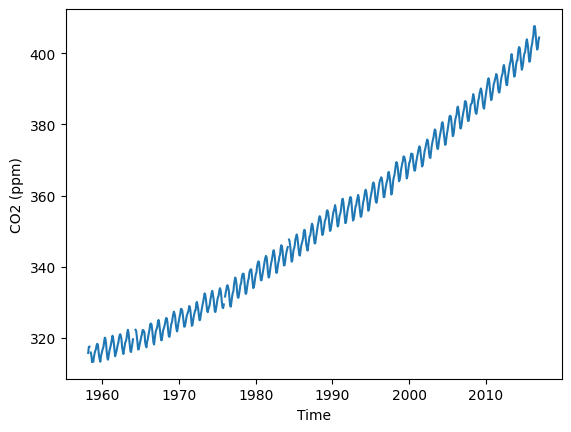

In [ ]:
fig, ax = plt.subplots()
ax.plot(climate_change.index, climate_change['co2'])
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm)')
plt.show()

## **Zooming on a decade**

- Use `.loc[]` to zoom at a particular time span
- Be careful that the time span used on the horizontal and vertical axes must be equal
- Missing values result in a blank line

In [ ]:
xfig, ax = plt.subplots()
ax.plot(climate_change.loc['1960-01-01':'1969-12-31'].index, climate_change.loc['1960-01-01':'1969-12-31']['co2'])
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm)')
plt.show()

## **Index changes accordingly**

- Below the index shows the month when timespan is restricted to be one year

In [ ]:
fig, ax = plt.subplots()
ax.plot(climate_change.loc['1969-01-01':'1969-12-31'].index, climate_change.loc['1969-01-01':'1969-12-31']['co2'])
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm)')
plt.show()

#### ***Exercise: Read data with a time index***

Pandas DataFrame objects can have an index that denotes time. This is useful because Matplotlib recognizes that these measurements represent time and labels the values on the axis accordingly.

In this exercise, you will read data from a CSV file called `climate_change.csv` that contains measurements of CO2 levels and temperatures made on the 6th of every month from 1958 until 2016.

To designate the index as a `DateTimeIndex`, you will use the `parse_dates` and `index_col` key-word arguments both to parse this column as a variable that contains dates and also to designate it as the index for this DataFrame.

* Use the `parse_dates` key-word argument to parse the `"date"` column as dates.
* Use the `index_col` key-word argument to set the `"date"` column as the index.

In [ ]:
import pandas as pd

# Read the data from file using read_csv
climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

#### ***Exercise: Plot time-series data***

To plot time-series data, we use the **Axes** object **`plot`** command.

- The first argument to this method are the values for the x-axis
- The second argument are the values for the y-axis.

This exercise provides data stored in a DataFrame called `climate_change`. This variable has a time-index with the dates of measurements and two data columns: `"co2"` and `"relative_temp"`.

In this case, the index of the DataFrame would be used as the x-axis values and we will plot the values stored in the `"relative_temp"` column as the y-axis values. We will also properly label the x-axis and y-axis.

#### ***Instructions***

* Add the data from `climate_change` to the plot: use the DataFrame index for the x value and the `"relative_temp"` column for the y values.
* Set the x-axis label to `'Time'`.
* Set the y-axis label to `'Relative temperature (Celsius)'`.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the data from file using read_csv
climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

fig, ax = plt.subplots()

# Add the time-series for "relative_temp" to the plot
ax.plot(climate_change.index, climate_change['relative_temp'])

# Set the x-axis label
ax.set_xlabel('Time')

# Set the y-axis label
ax.set_ylabel('Relative temperature (Celsius)')

# Show the figure
plt.show()

#### ***Exercise: Using a time index to zoom in***

When a time-series is represented with a time index, we can use this index for the x-axis when plotting. We can also select a to zoom in on a particular period within the time-series using Pandas' indexing facilities. In this exercise, you will select a portion of a time-series dataset and you will plot that period.

#### ***Instructions***

* Use **`plt.subplots`** to create a Figure with one Axes called `fig` and `ax`, respectively.
* Create a variable called `seventies` that includes all the data between `"1970-01-01"` and `"1979-12-31"`.
* Add the data from `seventies` to the plot: use the DataFrame index for the x value and the `"co2"` column for the y values.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the data from file using read_csv
climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])


# Use plt.subplots to create fig and ax
fig, ax = plt.subplots()

# Create variable seventies with data from "1970-01-01" to "1979-12-31"
seventies = climate_change['1970-01-01':'1979-12-31']

# Add the time-series for "co2" data from seventies to the plot
ax.plot(seventies.index, seventies["co2"])

# Show the figure
plt.show()

# **Plotting multiple time-series with different scales**

* Problem with scale on y-axis.

In [ ]:
fig, ax = plt.subplots()
ax.plot(climate_change.index, climate_change['co2'])
ax.plot(climate_change.index, climate_change['relative_temp'])
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm), Relative Temperature')
plt.show()

The scales for these two measurements are different.  You can choose to plot them in separate subplots, but in case you want to plot them in the same figure...

## ***Plotting two time series with different y-scale***

Use **`ax2=ax.twinx()`**

- Share the same x-axis
- y-axes' scales are different on the left and on the right

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the data from file using read_csv
climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(climate_change.index, climate_change["co2"], label='co2')
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm)', color='blue')
ax.tick_params('y', colors='blue')

ax2 = ax.twinx()  # A twin copy of x-axis.  No need for fig, ax again.
ax2.plot(climate_change.index, climate_change["relative_temp"], label='temperature', color='red')
ax2.set_ylabel('Relative temperature (Celsius)', color='red')
ax2.tick_params('y', colors='red')

# The code below is for when you want to have legend on the axis.
# handles,labels = [],[]
# for ax in fig.axes:
#     for h,l in zip(*ax.get_legend_handles_labels()):
#         handles.append(h)
#         labels.append(l)
# plt.legend(handles,labels)

fig.legend()

plt.show()


The above show the fluctuation in temperature more clearly

#### ***Exercise: Plotting two variables***

If you want to plot two time-series variables that were recorded at the same times, you can add both of them to the same subplot.

If the variables have very different scales, you'll want to make sure that you plot them in different twin Axes objects. These objects can share one axis (for example, the time, or x-axis) while not sharing the other (the y-axis).

To create a twin Axes object that shares the x-axis, we use the **`.twinx()`** method.

In this exercise, you'll have access to a DataFrame that has the `climate_change` data loaded into it. This DataFrame was loaded with the `"date"` column set as a `DateTimeIndex`, and it has a column called `"co2"` with carbon dioxide measurements and a column called `"relative_temp"` with temperature measurements.

#### ***Instructions***

* Use **`plt.subplots`** to create a Figure and Axes objects called `fig` and `ax`, respectively.
* Plot the carbon dioxide variable in blue using the Axes plot method.
* Use the Axes **`.twinx()`** method to create a twin Axes that shares the x-axis.
* Plot the relative temperature variable in red on the twin Axes using its plot method.

In [ ]:
import matplotlib.pyplot as plt

# Initalize a Figure and Axes
fig, ax = plt.subplots()

# Plot the CO2 variable in blue
ax.plot(climate_change.index, climate_change['co2'], color='blue')

# Create a twin Axes that shares the x-axis
ax2 = ax.twinx()

# Plot the relative temperature in red
ax2.plot(climate_change.index, climate_change['relative_temp'], color='red')

plt.show()

#### ***Exercise: Defining a function that plots time-series data***

Once you realize that a particular section of code that you have written is useful, it is a good idea to define a function that saves that section of code for you, rather than copying it to other parts of your program where you would like to use this code.

Here, we will define a function that takes inputs such as a time variable and some other variable and plots them as x and y inputs. Then, it sets the labels on the x- and y-axis and sets the colors of the y-axis label, the y-axis ticks and the tick labels.

#### ***Instructions***

* Define a function called `plot_timeseries` that takes as input an Axes object (`axes`), data (`x`,`y`), a string with the name of a color and strings for x- and y-axis labels.
* Plot y as a function of in the color provided as the input `color`.
* Set the x- and y-axis labels using the provided input xlabel and ylabel, setting the y-axis label color using `color`.
* Set the y-axis tick parameters using the `tick_params` method of the Axes object, setting the colors key-word to `color`.

In [ ]:
# Define a function called plot_timeseries
def plot_timeseries(axes, x, y, color, xlabel, ylabel):

  # Plot the inputs x,y in the provided color
  axes.plot(x, y, color=color)

  # Set the x-axis label
  axes.set_xlabel(xlabel)

  # Set the y-axis label
  axes.set_ylabel(ylabel, color=color)

  # Set the colors tick params for y-axis
  axes.tick_params('y', colors=color)

#### ***Exercise: Using a plotting function***

Plot the `climate_change` time-series data, provided as a Pandas DataFrame object that has a `DateTimeIndex` with the dates of the measurements and `co2` and `relative_temp` columns.

* In the provided `ax` object, use the function `plot_timeseries` to plot the `"co2"` column in blue, with the x-axis label `"Time (years)"` and y-axis label `"CO2 levels"`.
* Use the `ax.twinx` method to add an Axes object to the figure that shares the x-axis with `ax`.
* Use the function `plot_timeseries` to add the data in the `"relative_temp"` column in red to the twin Axes object, with the x-axis label `"Time (years)"` and y-axis label `"Relative temperature (Celsius)"`.

In [ ]:
fig, ax = plt.subplots()

# Plot the CO2 levels time-series in blue
plot_timeseries(ax, climate_change.index, climate_change['co2'], "blue", 'Time (years)', 'CO2 levels')

# Create a twin Axes object that shares the x-axis
ax2 = ax.twinx()

# Plot the relative temperature data in red
plot_timeseries(ax2, climate_change.index, climate_change['relative_temp'], "red", 'Time (years)', 'Relative temperature (Celsius)')

plt.show()

# ***Annotation***

- Use
```python
ax.annotate("string we want",
            xy=(num_x, num_y),
            xytext=(num_x_text, num_y_text),
            arrowprops={})  # arrowsprops is dict
```

- Look more by yourself at https://matplotlib.org/users/annotations.html

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the data from file using read_csv
climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(climate_change.index, climate_change["co2"], label='co2')
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm)', color='blue')
ax.tick_params('y', colors='blue')

ax2 = ax.twinx()
ax2.plot(climate_change.index, climate_change["relative_temp"], label='temperature', color='red')
ax2.set_ylabel('Relative temperature (Celsius)', color='red')
ax2.tick_params('y', colors='red')

######################
##### Annotation #####
######################
ax2.annotate(">1 degree", xy=[pd.Timestamp("2015-10-06"), 1])

handles,labels = [],[]
for ax in fig.axes:
    for h,l in zip(*ax.get_legend_handles_labels()):
        handles.append(h)
        labels.append(l)

plt.legend(handles,labels)
plt.show()

## ***Positioning the text***



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the data from file using read_csv
climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(climate_change.index, climate_change["co2"], label='co2')
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm)', color='blue')
ax.tick_params('y', colors='blue')

ax2 = ax.twinx()
ax2.plot(climate_change.index, climate_change["relative_temp"], label='temperature', color='red')
ax2.set_ylabel('Relative temperature (Celsius)', color='red')
ax2.tick_params('y', colors='red')

# Annotation
ax2.annotate(">1 degree", xy=[pd.Timestamp("2015-10-06"), 1])

# Positioning
ax2.annotate(">1 degree", xy=(pd.Timestamp('2015-10-06'), 1),
             xytext=(pd.Timestamp('2008-10-06'), -0.2))

# โค้ดนี้มีไว้เพราะถ้าไม่มี legend มันจะหายไปหนึ่งตัว เพราะอะไรไม่รู้
handles,labels = [],[]
for ax in fig.axes:
    for h,l in zip(*ax.get_legend_handles_labels()):
        handles.append(h)
        labels.append(l)

plt.legend(handles,labels)
plt.show()

## ***Adding arrows to annotation***

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the data from file using read_csv
climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(climate_change.index, climate_change["co2"], label='co2')
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm)', color='blue')
ax.tick_params('y', colors='blue')

ax2 = ax.twinx()
ax2.plot(climate_change.index, climate_change["relative_temp"], label='temperature', color='red')
ax2.set_ylabel('Relative temperature (Celsius)', color='red')
ax2.tick_params('y', colors='red')

# Adding arrow
ax2.annotate(">1 degree", xy=(pd.Timestamp('2015-10-06'), 1),
             xytext=(pd.Timestamp('2008-10-06'), -0.2), arrowprops={})

handles,labels = [],[]
for ax in fig.axes:
    for h,l in zip(*ax.get_legend_handles_labels()):
        handles.append(h)
        labels.append(l)


plt.legend(handles,labels)
plt.show()

## ***Customizing arrow properties***



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the data from file using read_csv
climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(climate_change.index, climate_change["co2"], label='co2')
ax.set_xlabel('Time')
ax.set_ylabel('CO2 (ppm)', color='blue')
ax.tick_params('y', colors='blue')

ax2 = ax.twinx()
ax2.plot(climate_change.index, climate_change["relative_temp"], label='temperature', color='red')
ax2.set_ylabel('Relative temperature (Celsius)', color='red')
ax2.tick_params('y', colors='red')

# Customizing arrow
ax2.annotate(">1 degree", xy=(pd.Timestamp('2015-10-06'), 1), xytext=(pd.Timestamp('2008-10-06'), -0.2),
            arrowprops={"arrowstyle":"->", "color":"green"})

# โค้ดนี้มีไว้เพราะถ้าไม่มี legend มันจะหายไปหนึ่งตัว เพราะอะไรไม่รู้
handles,labels = [],[]
for ax in fig.axes:
    for h,l in zip(*ax.get_legend_handles_labels()):
        handles.append(h)
        labels.append(l)


plt.legend(handles,labels)
plt.show()

#### ***Exercise: Annotating a plot of time-series data***
                                                                                                                                      
Annotating a plot allows us to highlight interesting information in the plot. For example, in describing the climate change dataset, we might want to point to the date at which the relative temperature first exceeded 1 degree Celsius.

For this, we will use the annotate method of the **Axes** object. In this exercise, you will have the DataFrame called `climate_change` loaded into memory. Using the **Axes** methods, plot only the relative temperature column as a function of dates, and annotate the data.

#### ***Instructions***

* Use the `ax.plot` method to plot the DataFrame index against the `relative_temp` column.
Use the annotate method to add the text `'>1 degree'` in the location (`pd.Timestamp('2015-10-06'), 1)`.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the data from file using read_csv
climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

fig, ax = plt.subplots()

# Plot the relative temperature data
ax.plot(climate_change.index, climate_change['relative_temp'])

# Annotate the date at which temperatures exceeded 1 degree
ax.annotate('>1 degree', xy=(pd.Timestamp('2015-10-06'), 1))

plt.show()

#### ***Exercise: Plotting time-series: putting it all together***

* Use the `plot_timeseries` function to plot `CO2` levels against time. Set xlabel to `"Time (years)"` ylabel to `"CO2 levels"` and color to `'blue'`.
* Create `ax2`, as a twin of the first Axes.
* In `ax2`, plot temperature against time, setting the color ylabel to `"Relative temp (Celsius)"` and color to `'red'`.
* Annotate the data using the `ax2.annotate` method. Place the text `">1 degree"` in `x=pd.Timestamp('2008-10-06')`, `y=-0.2` pointing with a `gray` thin arrow to `x=pd.Timestamp('2015-10-06'), y = 1`.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

def plot_timeseries(axes, x, y, color, xlabel, ylabel):
    axes.plot(x, y, color=color)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel, color=color)
    axes.tick_params('y', colors=color)

fig, ax = plt.subplots()

# Plot the CO2 levels time-series in blue
plot_timeseries(ax, climate_change.index, climate_change['co2'], 'blue', 'Time (years)', 'CO2 levels')

# Create an Axes object that shares the x-axis
ax2 = ax.twinx()

# Plot the relative temperature data in red
plot_timeseries(ax2, climate_change.index, climate_change['relative_temp'], 'red', 'Time (years)', 'Relative temp (Celsius)')

# Annotate point with relative temperature >1 degree
ax2.annotate(">1 degree", xy=(pd.Timestamp('2015-10-06'), 1), xytext=(pd.Timestamp('2008-10-06'), -0.2), arrowprops={"arrowstyle":"->", "color":"gray"})

plt.show()

# **Quantitative comparisons and statistical visualizations**

## ***Bar Charts***

In [ ]:
medals = pd.read_csv('medals_by_country_2016.csv', index_col=0).sort_values('Gold', ascending=False)
medals

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

medals = pd.read_csv('medals_by_country_2016.csv', index_col=0).sort_values('Gold', ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(medals.index, medals["Gold"])
ax.set_xticklabels(medals.index, rotation=45)
ax.set_xlabel('Coountries')
ax.set_ylabel('Number of Medals')
plt.show()

## ***Stacked Bar Charts***

- Layer more bars on existing bars
- This is hard to understand in my opinion

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

medals = pd.read_csv('medals_by_country_2016.csv', index_col=0).sort_values('Gold', ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(medals.index, medals["Gold"], label='Gold')
ax.bar(medals.index, medals["Silver"], bottom=medals["Gold"], label='Silver')
ax.set_xticklabels(medals.index, rotation=45)
ax.set_xlabel('Coountries')
ax.set_ylabel('Number of Medals')
ax.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

medals = pd.read_csv('medals_by_country_2016.csv', index_col=0).sort_values('Gold', ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(medals.index, medals["Gold"], label='Gold')
ax.bar(medals.index, medals["Silver"], bottom=medals["Gold"], label='Silver')
ax.bar(medals.index, medals["Bronze"],
bottom=medals["Gold"] + medals["Silver"], label='Bronze')
ax.set_xticklabels(medals.index, rotation=90)
ax.set_ylabel("Number of medals")
ax.legend()
plt.show()

## ***Multiple separated bar charts***
Using separated bars is easier to interpret


In [ ]:
medals = pd.read_csv('medals_by_country_2016.csv', index_col=0).sort_values(['Gold', 'Silver', 'Bronze' ], ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df))
width = 0.25

ax.bar(x - width, medals['Gold'], width, label='Gold')
ax.bar(x,         medals['Silver'], width, label='Silver')
ax.bar(x + width, medals['Bronze'], width, label='Bronze')

ax.set_xticks(x)
ax.set_xticklabels(medals.index, rotation=45)

ax.set_xlabel('Country')
ax.set_ylabel('Number of medals')
ax.legend(title='Medal')

plt.show()

Using **`df.plot()`** is even easier.



In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
medals.plot( y=['Gold', 'Silver', 'Bronze'], kind='bar', ax=ax )
ax.set_xlabel('Country')
ax.set_ylabel('Number of medals')
ax.legend(title='Medal')
plt.show()

# ***Histograms***

In [ ]:
df = pd.read_csv('summer2016.csv').drop(columns='Unnamed: 0')
mens_rowing = df[(df['Sport']=='Rowing') & (df['Sex']=='M')]
mens_gymnastics = df[(df['Sport']=='Gymnastics') & (df['Sex']=='M')]
mens_rowing.head()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('summer2016.csv').drop(columns='Unnamed: 0')
mens_rowing = df[(df['Sport']=='Rowing') & (df['Sex']=='M')]
mens_gymnastics = df[(df['Sport']=='Gymnastics') & (df['Sex']=='M')]

# Bar charts can only show just one value, usually the mean
fig, ax = plt.subplots()
ax.bar("Rowing", mens_rowing["Height"].mean())
ax.bar("Gymnastics", mens_gymnastics["Height"].mean())
ax.set_ylabel("Height (cm)")
plt.show()

# Histograms
fig, ax = plt.subplots()
ax.hist(mens_rowing["Height"], label='Rowing', edgecolor='black')
ax.hist(mens_gymnastics["Height"], label='Gymnastics', edgecolor='black')
ax.set_xlabel("Height (cm)")
ax.set_ylabel("# of observations")
ax.legend()
plt.show()

# Transparent Histograms
fig, ax = plt.subplots()
ax.hist(mens_rowing["Height"], label='Rowing', bins=20, histtype='step')
ax.hist(mens_gymnastics["Height"], label='Gymnastics', bins=20, histtype='step')
ax.set_xlabel("Height (cm)")
ax.set_ylabel("# of observations")
ax.legend()
plt.show()

#### ***Exercise: Creating histograms***

Histograms show the full distribution of a variable. In this exercise, we will display the distribution of weights of medalists in gymnastics and in rowing in the 2016 Olympic games for a comparison between them.

You will have two DataFrames to use. The first is called `mens_rowing` and includes information about the medalists in the men's rowing events. The other is called `mens_gymnastics` and includes information about medalists in all of the Gymnastics events.

#### ***Instructions***

* Use the `ax.hist` method to add a histogram of the `"Weight"` column from the `mens_rowing` DataFrame.
* Use `ax.hist` to add a histogram of "`Weight"` for the `mens_gymnastics` DataFrame.
* Set the x-axis label to `"Weight (kg)"` and the y-axis label to `"# of observations"`.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('summer2016.csv').drop(columns='Unnamed: 0')
mens_rowing = df[(df['Sport']=='Rowing') & (df['Sex']=='M')]
mens_gymnastics = df[(df['Sport']=='Gymnastics') & (df['Sex']=='M')]

fig, ax = plt.subplots()
# Plot a histogram of "Weight" for mens_rowing
ax.hist(mens_rowing['Weight'], label='rowing')

# Compare to histogram of "Weight" for mens_gymnastics
ax.hist(mens_gymnastics['Weight'], label='gymnastics')

# Set the x-axis label to "Weight (kg)"
ax.set_xlabel('Weight (kg)')

# Set the y-axis label to "# of observations"
ax.set_ylabel('# of observations')
ax.legend()

plt.show()

#### ***Transparent histogram***

The data is stored in a Pandas DataFrame object called `summer_2016_medals` that has a column `"Height"`. In addition, you are provided a Pandas GroupBy object that has been grouped by the sport.

In this exercise, you will visualize and label the histograms of two sports: `"Gymnastics"` and `"Rowing"` and see the marked difference between medalists in these two sports.

#### ***Instructions***

* Use the **`hist`** method to display a histogram of the `"Weight"` column from the `mens_rowing` DataFrame, label this as `"Rowing"`.
* Use **`hist`** to display a histogram of the `"Weight"` column from the `mens_gymnastics` DataFrame, and label this as `"Gymnastics"`.
* For both histograms, use the `histtype` argument to visualize the data using the `'step'` type and set the number of `bins` to use to `5`.
* Add a legend to the figure, before it is displayed.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('summer2016.csv').drop(columns='Unnamed: 0')
mens_rowing = df[(df['Sport']=='Rowing') & (df['Sex']=='M')]
mens_gymnastics = df[(df['Sport']=='Gymnastics') & (df['Sex']=='M')]

fig, ax = plt.subplots()

# Plot a histogram of "Weight" for mens_rowing
ax.hist(mens_rowing['Weight'], label='Rowing', histtype='step', bins=5)

# Compare to histogram of "Weight" for mens_gymnastics
ax.hist(mens_gymnastics['Weight'], label='Gymnastics', histtype='step', bins=5)

ax.set_xlabel("Weight (kg)")
ax.set_ylabel("# of observations")

# Add the legend and show the Figure
ax.legend()
plt.show()

# **Statistical Plotting**

## ***Adding error bars to bar charts***

- Use the keyword argument **`yerr=`**
- Put the standard deviation of the data by **`.std()`**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('summer2016.csv').drop(columns='Unnamed: 0')
mens_rowing = df[(df['Sport']=='Rowing') & (df['Sex']=='M')]
mens_gymnastics = df[(df['Sport']=='Gymnastics') & (df['Sex']=='M')]

fig, ax = plt.subplots()
ax.bar("Rowing", mens_rowing["Height"].mean(), yerr=mens_rowing["Height"].std())
ax.bar("Gymnastics", mens_gymnastics["Height"].mean(), yerr=mens_gymnastics["Height"].std())
ax.set_ylabel("Height (cm)")
plt.show()

## ***Adding error bars to line plots***
- Use **`ax.errorbar(x, y, yerr=)`**
- It looks like you need to have a separated columns for standard deviations at each observations

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

seattle_weather = pd.read_csv('seattle_weather.csv').iloc[:12]
austin_weather = pd.read_csv('austin_weather.csv').iloc[:12]
month = {1: 'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
seattle_weather['MONTH'] = seattle_weather['DATE'].map(month)
austin_weather['MONTH'] = austin_weather['DATE'].map(month)

fig, ax = plt.subplots()

ax.errorbar(seattle_weather["MONTH"],seattle_weather["MLY-TAVG-NORMAL"], yerr=seattle_weather["MLY-TAVG-STDDEV"])
ax.errorbar(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"], yerr=austin_weather["MLY-TAVG-STDDEV"])
ax.set_ylabel("Temperature (Fahrenheit)")
plt.show()

## ***Adding boxplots***

- Use **`ax.boxplot()`**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('summer2016.csv').drop(columns='Unnamed: 0')
mens_rowing = df[(df['Sport']=='Rowing') & (df['Sex']=='M')]
mens_gymnastics = df[(df['Sport']=='Gymnastics') & (df['Sex']=='M')]

fig, ax = plt.subplots()
ax.boxplot([mens_rowing["Height"], mens_gymnastics["Height"]])
ax.set_xticklabels(["Rowing", "Gymnastics"])
ax.set_ylabel("Height (cm)")
plt.show()

# ***Scatter Plots***

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

fig, ax = plt.subplots()
ax.scatter(climate_change["co2"], climate_change["relative_temp"])
ax.set_xlabel("CO2 (ppm)")
ax.set_ylabel("Relative temperature (Celsius)")
plt.show()

## ***Customizing scatter plots***

- Below is adding colors to separated columns, simpler than what we did before

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

eighties = climate_change["1980-01-01":"1989-12-31"]
nineties = climate_change["1990-01-01":"1999-12-31"]

fig, ax = plt.subplots()
ax.scatter(eighties["co2"], eighties["relative_temp"], color="red", label="eighties")
ax.scatter(nineties["co2"], nineties["relative_temp"], color="blue", label="nineties")
ax.legend()
ax.set_xlabel("CO2 (ppm)")
ax.set_ylabel("Relative temperature (Celsius)")
plt.show()

## ***Encoding a third variable by color***


>> This is related to what we did

- Use **`c`** keyword argument
- Dark points early on and light points later

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

climate_change = pd.read_csv('climate_change.csv', index_col='date', parse_dates=['date'])

fig, ax = plt.subplots()
ax.scatter(climate_change["co2"], climate_change["relative_temp"], c=climate_change.index)
ax.set_xlabel("CO2 (ppm)")
ax.set_ylabel("Relative temperature (Celsius)")
plt.show()

Unfortunately the formal treatment using **`matplotlib`** on scatterplot is less interesting than what you did in the previous section

# **Preparing figures to share with others**


## ***Changing Plot Style***

https://matplotlib.org/gallery/style_sheets/style_sheets_reference.html

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

seattle_weather = pd.read_csv('seattle_weather.csv').iloc[:12]
austin_weather = pd.read_csv('austin_weather.csv').iloc[:12]
month = {1: 'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
seattle_weather['MONTH'] = seattle_weather['DATE'].map(month)
austin_weather['MONTH'] = austin_weather['DATE'].map(month)

plt.style.use('ggplot') # plt.style.use('default') <<< Back to default

fig, ax = plt.subplots()
ax.plot(seattle_weather["MONTH"], seattle_weather["MLY-TAVG-NORMAL"])
ax.plot(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"])
ax.set_xlabel("Time (months)")
ax.set_ylabel("Average temperature (Fahrenheit degrees)")
plt.show()

## **Guidelines for choosing plot style**

- You can consult this on the [datacamp course video](https://campus.datacamp.com/courses/introduction-to-data-visualization-with-matplotlib/sharing-visualizations-with-others).  I found it not important to discuss here.

#### ***Exercise: Switching between styles***

Selecting a style to use affects all of the visualizations that are created after this style is selected.

Here, you will practice plotting data in two different styles. The data you will use is the same weather data we used in the first lesson: you will have available to you the DataFrame `seattle_weather` and the DataFrame `austin_weather`, both with records of the average temperature in every month.
#### ***Instructions***
* Select the `'ggplot'` style, create a new Figure called `fig`, and a new Axes object called `ax` with `plt.subplots`.
* Select the `'Solarize_Light2'` style, create a new Figure called `fig`, and a new Axes object called `ax` with `plt.subplots`.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

seattle_weather = pd.read_csv('seattle_weather.csv').iloc[:12]
austin_weather = pd.read_csv('austin_weather.csv').iloc[:12]
month = {1: 'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
seattle_weather['MONTH'] = seattle_weather['DATE'].map(month)
austin_weather['MONTH'] = austin_weather['DATE'].map(month)

# Use the "ggplot" style and create new Figure/Axes
# plt.style.available shows all available styles
plt.style.use('ggplot')
fig, ax = plt.subplots()
ax.plot(seattle_weather["MONTH"], seattle_weather["MLY-TAVG-NORMAL"])
plt.show()

# Use the "Solarize_Light2" style and create new Figure/Axes
plt.style.use('Solarize_Light2')
fig, ax = plt.subplots()
ax.plot(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"])
plt.show()


The style will only apply to a figure that is created after the style to use is selected.

# ***Saving the figure to file***

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

medals = pd.read_csv('medals_by_country_2016.csv', index_col=0).sort_values('Gold', ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(medals.index, medals["Gold"])
ax.set_xticklabels(medals.index, rotation=45)
ax.set_xlabel('Coountries')
ax.set_ylabel('Number of Medals')
plt.show()

### Save the figure ###
fig.savefig("gold_medals.png")

#### ***Exercise: Saving a file several times***

If you want to share your visualizations with others, you will need to save them into files. Matplotlib provides as way to do that, through the **`.savefig`** method of the Figure object. In this exercise, you will save a figure several times. Each time setting the parameters to something slightly different. We have provided and already created Figure object.
#### ***Instructions***
* Examine the figure by calling the **`plt.show(`**) function.
* Save the figure into the file `my_figure.png`, using the default resolution.
* Save the figure into the file `my_figure_300dpi.png` and set the resolution to `300` dpi.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

medals = pd.read_csv('medals_by_country_2016.csv', index_col=0).sort_values('Gold', ascending=False)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(medals.index, medals["Gold"])
ax.set_xticklabels(medals.index, rotation=45)
ax.set_xlabel('Coountries')
ax.set_ylabel('Number of Medals')
plt.show()

# Save as a PNG file
fig.savefig('my_figure.png')

# Save as a PNG file with 300 dpi
fig.savefig('my_figure_300dpi.png', dpi=300)

#### ***Exercise: Save a figure with different sizes***

Before saving your visualization, you might want to also set the size that the figure will have on the page. To do so, you can use the Figure object's **`set_size_inches`** method. This method takes a sequence of two values. The first sets the width and the second sets the height of the figure.

Here, you will again have a Figure object called `fig` already provided (you can run **`plt.show`** if you want to see its contents). Use the Figure methods **`set_size_inches`** and **`savefig`** to change its size and save two different versions of this figure.

* Set the figure size as width of `3` inches and height of `5` inches and save it as `'figure_3_5.png'` with default resolution.
* Set the figure size to width of `5` inches and height of `3` inches and save it as `'figure_5_3.png'` with default settings.

In [ ]:
# Set figure dimensions and save as a PNG
fig.set_size_inches([3, 5])
fig.savefig('figure_3_5.png')

# Set figure dimensions and save as a PNG
# Set figure dimensions and save as a PNG
fig.set_size_inches([5, 3])
fig.savefig('figure_5_3.png')

# ***Bar-chart of heights for all sports***

In [ ]:
summer_2016_medals = pd.read_csv('summer2016.csv').drop(columns='Unnamed: 0')
df = summer_2016_medals.groupby('Sport')[["Height"]].agg(['mean', 'std']).sort_values(by=('Height', 'mean'), ascending=False)
fig, ax = plt.subplots()
ax.bar(df.index, df[('Height', 'mean')], yerr=df[('Height',  'std')])
ax.set_ylabel("Height (cm)")
ax.set_xticklabels(df.index, rotation=75)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

summer_2016_medals = pd.read_csv('summer2016.csv').drop(columns='Unnamed: 0')

fig, ax = plt.subplots(figsize=(17,7))
for sport in summer_2016_medals["Sport"].unique():
    sport_df = summer_2016_medals[summer_2016_medals["Sport"] == sport]
    ax.bar(sport, sport_df["Height"].mean(), yerr=sport_df["Height"].std())
ax.set_ylabel("Height (cm)")
ax.set_xticklabels(summer_2016_medals["Sport"].unique(), rotation=75)
plt.show()

#### ***Exercise: Automate your visualization***

One of the main strengths of Matplotlib is that it can be automated to adapt to the data that it receives as input. For example, if you receive data that has an unknown number of categories, you can still create a bar plot that has bars for each category.

This is what you will do in this exercise. You will be visualizing data about medal winners in the 2016 summer Olympic Games again, but this time you will have a dataset that has some unknown number of branches of sports in it. This will be loaded into memory as a Pandas DataFrame object called `summer_2016_medals`, which has a column called `"Sport"` that tells you to which branch of sport each row corresponds. There is also a `"Weight"` column that tells you the weight of each athlete.
#### ***Instructions***
* Iterate over the values of `sports` setting `sport` as your loop variable.
* In each iteration, extract the rows where the `"Sport"` column is equal to `sport`.
* Add a bar to the provided `ax` object, labeled with the sport name, with the mean of the `"Weight"` column as its height, and the standard deviation as a y-axis error bar.
* Save the figure into the file `"sports_weights.png"`.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

summer_2016_medals = pd.read_csv('summer2016.csv').drop(columns='Unnamed: 0')

fig, ax = plt.subplots(figsize=(19, 7))

sports = summer_2016_medals["Sport"].unique()

# Loop over the different sports branches
for sport in sports:
    # Extract the rows only for this sport
    sport_df = summer_2016_medals[summer_2016_medals['Sport']==sport]
    # Add a bar for the "Weight" mean with std y error bar
    ax.bar(sport, sport_df['Weight'].mean(), yerr=sport_df['Weight'].std())

ax.set_ylabel("Weight")
ax.set_xticklabels(sports, rotation=70)

# Save the figure to file
plt.show()
fig.savefig("sports_weights.png")

https://matplotlib.org/gallery.html

https://matplotlib.org/mpl_toolkits/mplot3d/tutorial.html

https://matplotlib.org/users/image_tutorial.html

https://matplotlib.org/api/animation_api.html

https://scitools.org.uk/cartopy/docs/latest/